# Notes

Upon looking properly at the points extracted all over Africa, if precipitation is incredibly low we get crazy fourier results, which is, however, quite expected given how weak the signal is. I hink the first step should therefore be (1) predict precipitation values normally, if they are above a certain range we proceed to (2) predicting whether a double cycle is present using logistic regression, (3) adjusting the precipitation values, and reconstructing the climatographs.

Seeing as I now have data that is more complete for each point I think the phase values would be best derived from the entire spectra.

There was something about axis tilt. Also need to look at some form of air current that is conditioning the dual percipitation cycles. JUst all of these thigns are necessary to correct and adapt the models.

Krigging of earth phase could produce some very interesting maps...

I think in the end im going to model all percipitation as two cosine waves with independent phase and amplitudes

$$
T(t) = \mu_T + A_{T_{1}} \:\cos \left( \frac{2\pi}{12}t + \phi_{T_{1}} \right) + A_{T_{2}} \:\cos \left( \frac{2\pi}{6}t + \phi_{T_{2}} \right)
$$

$$
P(t) = \mu_P + A_{P_{1}} \:\cos \left( \frac{2\pi}{12}t + \phi_{P_{1}} \right) + A_{P_{2}} \:\cos \left( \frac{2\pi}{6}t + \phi_{P_{2}}\right)
$$

$$
A_{X} \sim \alpha + \beta_{\text{HOP}} \: \text{HOP} + \beta_{\text{LOP}} \: \log\left(\text{LOP} + 2\times 10^{-6}\right) \;\; \forall \;\; X \in [P, T]
$$

$$
\mu_{X} \sim \alpha + \beta_{\text{HOP}} \: \text{HOP} + \beta_{\text{LOP}} \log\left(\text{LOP} \: + 2\times 10^{-6}\right) \;\; \forall \;\; X \in [P, T]
$$

$$
\phi_{X_{i}} \sim \alpha + \beta_{\text{lat}} \: \text{lat} + \beta_{\text{long}} \:\text{long} + \beta_{\text{elev}} \: \text{elev}  \;\; \forall \;\; X \in [P, T]
$$

### Note

Because the way fft calculates phase it should actually be

$$
T(t) = \mu_T + A_{T_{1}} \:\cos \left( \frac{2\pi}{12}t - \phi_{T_{1}} \right) + A_{T_{2}} \:\cos \left( \frac{2\pi}{6}t - \phi_{T_{2}} \right)
$$

$$
P(t) = \mu_P + A_{P_{1}} \:\cos \left( \frac{2\pi}{12}t - \phi_{P_{1}} \right) + A_{P_{2}} \:\cos \left( \frac{2\pi}{6}t - \phi_{P_{2}}\right)
$$



# Problem

$\phi$ is a spatially autocorrelated variable therefore the model presented above is slightly too simplistic. Another issue is that variations in the earths tilt and the eccentricity of the orbit will condition $\phi$ as well, and I will eventually have to take this into consideration. For now, lets strip down everything and work with the modern data and try to model $\phi$ using krigging techniques.

# Idea

Should $\phi_{X} \;\; \forall \;\; X \in [P, T]$ use a geodesic model or something which accounts for spatial autocorrelation?

# Krigging

The idea is to test a single realisation of a random field;

$$
Z(s), \;\; s \in D \subset \mathbb{R}^{d}
$$

where $s$ is a spatial location, and $Z(s)$ is a random variable at the location. We do not observe the whole field, but instead observer $Z(s_{1}),\dots,Z(s_{n})$ at $n$ discrete sample points, with the goal to predict $Z(s_{x})$ at an unsampled point $x$.

## The Variogram

The semivariogram is defined as

$$
\gamma (s_{i}, s_{j}) = \frac{1}{2} \text{Var} \left( Z(s_{i}) - Z(s_{j}) \right)
$$

As written, this model assumes we are studying specific pairs of locations, however we assume instead a concept of points being **Intrinsically stationary**, or intrinsic stationarity, to help solve the equation for given prections. We therefore create a separation vector; $h = s_{i} - s_{j}$, and thus solve for;

$$
\gamma (h) = \frac{1}{2} \text{Var} \left( Z(s + h) - Z(s) \right)
$$

If we further assume isotropic properties across our field, $\gamma (h)$ depends only on $||h||$, i.e. distance, not direction.

## The Empirical Variogram

Given our data, we estimate $\gamma (h)$ using Matherons method-of-moments estimator. This takes pairs of points, establishes a set of lag bins $h \pm \delta $, and average;

$$
\hat{\gamma} (h) = \frac{1}{2 | N(h)|} \sum_{(i,j)\in N(h)} \left(Z(s_{i}) - Z(s_{j}) \right)^{2}
$$

Where $N(h)$ is the set of point pairs whose separation falls in the bin around $h$. We therefore define our graph of lag against $\hat{\gamma}$ where we eventually fit a parametric model.

## The Krigging Model

We want a prediction function, $\hat{Z}(s_{x})$ for an unsampled location that is built as a linear combination of our observed data;

$$
\hat{Z}(s_{x}) = \sum_{i = 1}^{n} \lambda_{i} Z(s_{i})
$$

We therefore need to find the weights, $\lambda$ that will help us do this.

### Model Assumptions

**Unbiasedness**

  $$
  \mathbb{E} \left[ \hat{Z}\left( s_{x}\right) \right] = \mathbb{E} \left[ Z\left( s_{x}\right)   \right]
  $$
  
  since $\mathbb{E}[Z(s_{x})] = \mu$ for all $i$ (constant mean assumption)

  $$
  \mathbb{E} \left[ \sum_{i} \lambda_{i} Z(s_{i}) \right] = \mu \sum_{i} \lambda_{i} = \mu
  $$

  which forces the constraint

  $$
  \sum_{i=1}^{n} \lambda_{i} = 1
  $$

  This modelling choice ensures that the krigging weights sum to 1 to prevent bias in a case where we have an unknown constant mean 

**Minimum Variance**

Among all of the unbiased linear predictors, we want the one minimising the prediction error's variance;

$$
\sigma_{E}^{2} = \text{Var} \left( \hat{Z}(s_{x}) - Z(s_{x}) \right)
$$

This is commonly known as the **BLUP**; the Best Linear Unbiased Predictor.

**Expanding the Error Variance**

$$
\sigma_{E}^{2} = 2 \sum_{i} \lambda_{i} \gamma \left( s_{i}, s_{x} \right) - \sum_{i} \sum_{j} 
\lambda_{i} \lambda_{j} \gamma \left( s_{i}, s_{j} \right)
$$

**Constrained Optimisation**

We now minimise $\sigma_{E}^{2}$ subject to $\sum_{i} \lambda_{i} = 1$ by introducing the Lagrange multiplier $m$ and minimise;

$$
 L = \sigma_{E}^{2} - 2m \left( \sum_{i} \lambda_{i} - 1 \right)
$$

If we then consider taking the derivative $\partial L / \partial \lambda_{i} = 0 \quad \forall \quad i $, and $\partial L / \partial m = 0$, this gives us a linear system. This is known as the ordinary kriging equation;

$$
\sum_{j = 1}^{n} \lambda_{j} \gamma (s_{i}, s_{j}) + m = \gamma (s_{i}, s_{x}), \quad i = 1, \dots, n
$$

$$
\sum_{j = 1}^{n} \lambda_{j} = 1
$$

**Expanding for Matrix Notation**

Let $\Gamma$ be the $n \times n$ matrix of $\gamma(s_{i}, s_{j})$ between all sample pairs, $\gamma_{0}$ is then the vector of $\gamma_{s_{i}, s_{x}}$ between samples and the taget point, and 1 is a vector of ones;

$$
\begin{bmatrix}
    \Gamma & 1 \\
    1^{T} & 0
\end{bmatrix} \begin{bmatrix}
    \lambda \\
    m
\end{bmatrix} = \begin{bmatrix} \gamma_{x} \\ 1 \end{bmatrix}
$$

If we solve this system to get $\lambda$, we can then plug into $\hat{Z}(s_{x}) = \sum \lambda_{i} Z(s_{i})$. Finally we do not completely discard $m$, so we can get Kriging variance as;

$$
\sigma_{OK}^{2} = \sum_{i} \lambda_{i} \gamma(s_{i}, s_{x}) + m
$$

# The Spherical Model

The spherical model is given by;

$$
\gamma (h) = \begin{cases}
    c_{0} + c \left[ \frac{3h}{2a} - \frac{1}{2} \left( \frac{h}{a} \right)^{3} \right], & 0 < h \leq a \\
    c_{0} + c, & h>a \\
    0, & h=0
\end{cases}
$$

where $c_{0}$ is the nugget, $c$ is the partial sill, $c_{0} + c$ is the total sill and $a$ is the range.

The Spherical model behaves linearly near the origin and can be framed as a model that draws spheres around each point and models the overlap that occurs between them.

# The Exponential Model

The exponential model can be defined as;

$$
\gamma(h) = c_{0} + c \left[1 - e^{-\frac{h}{a}}\right], \quad h> 0
$$

# The Matérn model

The spherical and exponential model are pretty powerful models but have a limitation which is an approximation to linearity as we approach the nugget with a hard cutoff in the case of the spherical model. This imposes some issues that can often require smoothing. Models derived from the Matérn model are the best means of approaching this.

The Matérn model is defined as;

$$
\gamma (h) = c_{0} + c \left[ 1 - \frac{2^{1 - \nu}}{\Gamma (\nu)} \left( \frac{\sqrt{2 \nu} h}{a} \right)^{\nu} K_{\nu} \left( \frac{\sqrt{2 \nu} h}{a} \right) \right],\quad h>0
$$

While a large formula, mostly centered around a density coefficient $\nu$, this formula has many functional properties that make it powerful in its own right. $K_{\nu}$ is a modified Bessel function to impose smoothness, it shows up here because Matérn covariance functionas are the Fourier transform of a specific spectral density $\propto (1+||\omega||^{2})^{-\nu - d/2}$. $\Gamma(\nu)$ and $2^{1-\nu}$ are normalising constants to ensure $C(0) = \sigma^{2}$, and $\nu > 0$ is what defines smoothness.

$\nu$ is the core component of this formula as it defines how differentiable the equation is. If we set $\nu$ to 0.5, then the formula collapses to directly the exponential model, which is non-differentiable. Therefore, as we increase $\nu$ we can smooth out the function. For $\nu = 1.5$ the formula is now once differentiable, and much smoother. $\nu = 2.5$ makes the model now twice differentiable and quite smoother. $\nu \rightarrow \infty$ converges to a Gaussian model. Using a Matérn model, as opposed to directly jumping to the Gaussian model, can refine the model further, however $\nu$ should not be guessed, and is often estimated using maximum likelihood functions.

# The Gaussian Model

$$
\gamma (h) = c_{0} + c \left[ 1 - e^{-\frac{h^{2}}{a^{2}}} \right],\quad h> 0
$$

# Lets Build the Semivariogram

Ill start with modelling $\sin(\phi)$. THis will then have to build later to modelling $\cos(\phi)$ and the final step would be to build the final rastered model as $\text{atan2}(y, x)$.

We use $\sin(\phi)$ because $\phi \in (0, 2 \pi]$

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sklearn
import scipy
from scipy.optimize import curve_fit
import geopandas as gpd
from shapely.geometry import Point
import rasterio
from rasterio.transform import from_origin

print(f"Numpy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Scikit-Learn: {sklearn.__version__}")
print(f"Scipy: {scipy.__version__}")
print(f"GeoPandas: {gpd.__version__}")
print(f"RasterIO: {rasterio.__version__}")

data = pd.read_csv("FinalPhaseData.csv", delimiter = ";")
print(f"\n\nDataset Length: {len(data)}\n\n")

Numpy: 2.3.5
Pandas: 2.3.3
Matplotlib: 3.10.6
Scikit-Learn: 1.7.2
Scipy: 1.16.3
GeoPandas: 1.1.4
RasterIO: 1.5.1


Dataset Length: 590




First we need to compute $h$, however because my data is longitude and latitude based Euclidean distances will introduce errors, therefore we will resort to using Haversine distances. Longitude in this formual is usually written as $\lambda$ and latitude as $\phi$, however to avoid reduncancies with prior notation, we will use $\iota$ and $\psi$ respectively

$$
\Delta \psi_{ij} = \psi_{i} - \psi_{j}
$$

$$
\Delta \iota_{ij} = \iota_{i} - \iota_{j}
$$

$$
a_{ij} = \sin^{2} \left( \frac{\Delta \psi_{ij}}{2} \right) + \cos\left(\psi_{i}\right) + \cos \left( \psi_{j}\right) \sin^{2} \left( \frac{\Delta \iota_{ij}}{2} \right)
$$

$$
c_{ij} = 2 \: \text{arcsin}(\sqrt{a_{ij}})
$$

$$
d_{ij} = Rc
$$

where $R$ is the earths radius in km, usually set to 6371.

In [2]:
def haversine_distance_matrix(lon, lat):

    # radius of the earh in km
    
    R = 6371.0

    lon_rad = np.radians(lon)
    lat_rad = np.radians(lat)

    dlat = lat_rad[:, None] - lat_rad[None, :]
    dlon = lon_rad[:, None] - lon_rad[None, :]

    a = (
        np.sin(dlat / 2)**2 + np.cos(lat_rad[:, None]) * np.cos(lat_rad[None, :]) * np.sin(dlon / 2)**2
    )
    c = 2 * np.arcsin(np.sqrt(a))

    return(R * c)

$$
\hat{\gamma} (h) = \frac{1}{2 | N(h)|} \sum_{(i,j)\in N(h)} \left(Z(s_{i}) - Z(s_{j}) \right)^{2}
$$

In [3]:
def empirical_variogram(dist_matrix, z, n_bins = 15, max_lag = None):

    n = len(z)

    iu, ju = np.triu_indices(n, k = 1)

    h_values = dist_matrix[iu, ju]
    square_difference = (z[iu] - z[ju])**2

    if max_lag is None:
        
        max_lag = h_values.max() / 2

    bin_edges = np.linspace(0, max_lag, n_bins + 1)
    bin_index = np.digitize(h_values, bin_edges) - 1

    lag_centers = np.zeros(n_bins)
    gamma_hat = np.full(n_bins, np.nan)
    n_pairs = np.zeros(n_bins, dtype = int)

    for target_bin in range(n_bins):

        mask = bin_index == target_bin
        n_pairs[target_bin] = mask.sum()
        lag_centers[target_bin] = 0.5 * (bin_edges[target_bin] + bin_edges[target_bin + 1])

        if n_pairs[target_bin] > 0:

            gamma_hat[target_bin] = 0.5 * np.mean(square_difference[mask])

    return lag_centers, gamma_hat, n_pairs

def plot_variogram(lag_centers, gamma_hat, n_pairs, title="Empirical Semivariogram"):

    plt.figure(figsize=(8, 4))
    
    plt.scatter(lag_centers, gamma_hat, s=100, edgecolor='k', alpha=0.7)
    plt.ylabel(r'$\hat{\gamma}(h)$')
    plt.xlabel(r'$h$')
    plt.title(title)
    plt.ylim(0, np.max(gamma_hat) + np.std(gamma_hat))
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


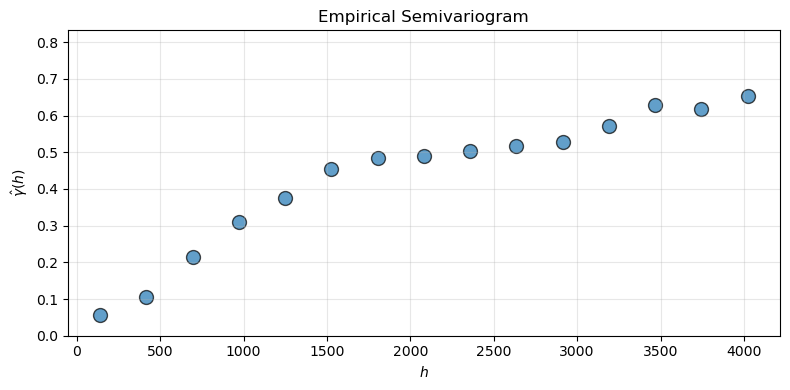

In [4]:
sin_phi = np.sin(data["TempPhi1"].values)
longitude = data["longitude"].values
latitude = data["latitude"].values

distance_matrix = haversine_distance_matrix(longitude, latitude)
lag_centers, gamma_hat, n_pairs = empirical_variogram(distance_matrix, sin_phi, n_bins = 15)
plot_variogram(lag_centers, gamma_hat, n_pairs)

$$
\gamma (h)_{\text{sph}} = \begin{cases}
    c_{0} + c \left[ \frac{3h}{2a} - \frac{1}{2} \left( \frac{h}{a} \right)^{3} \right], & 0 < h \leq a \\
    c_{0} + c, & h>a \\
    0, & h=0
\end{cases}
$$

In [5]:
def spherical_model(h, nugget, sill, emp_range):

    partial_sill = sill - nugget
    gamma = np.where(
        h <= emp_range,
        nugget + partial_sill * (1.5 * (h / emp_range) - 0.5 * (h / emp_range)**3),
        sill
    )

    gamma = np.where(h == 0, 0, gamma)

    return gamma

$$
\gamma(h)_{\text{exp}} = c_{0} + c \left[1 - e^{-\frac{h}{a}}\right], \quad h> 0
$$

In [6]:
def exponential_model(h, nugget, sill, emp_range):

    partial_sill = sill - nugget
    gamma = nugget + partial_sill * (1 - np.exp(-h / emp_range))
    gamma = np.where(h == 0, 0, gamma)

    return gamma

$$
\gamma (h)_{\text{gau}} = c_{0} + c \left[ 1 - e^{-\frac{h^{2}}{a^{2}}} \right],\quad h> 0
$$

In [7]:
def gaussian_model(h, nugget, sill, emp_range):

    partial_sill = sill - nugget
    gamma = nugget + partial_sill * (1 - np.exp(-(h**2) / (emp_range**2)))
    gamma = np.where(h == 0, 0, gamma)

    return gamma

In [8]:
def fit_variogram_model(model_func, lag_centers, gamma_hat, n_pairs, p0 = None, weighted = True):

    valid = n_pairs > 0 # remove any invalid bins based on pairs
    h = lag_centers[valid]
    g = gamma_hat[valid]
    w = n_pairs[valid]

    if p0 is None:

        nugget0 = g[0] if len(g) > 0 else 0.0
        sill0 = np.nanmax(g)
        range0 = h[np.nanargmax(g)] if np.nanargmax(g) > 0 else h.max() / 2
        p0 = [nugget0, sill0, range0]

    bounds = ([0, 0, 1e-6], [np.inf, np.inf, np.inf])

    if weighted:
        sigma = 1 / np.sqrt(w)
    else:
        sigma = None

    popt, pcov = curve_fit(
        model_func, h, g, p0 = p0, bounds = bounds,
        sigma = sigma, absolute_sigma = False, maxfev = 10000
    )

    return popt, pcov

In [9]:
gaus_variables, gaus_cov = fit_variogram_model(gaussian_model, lag_centers, gamma_hat, n_pairs)
sph_variables, sph_cov = fit_variogram_model(spherical_model, lag_centers, gamma_hat, n_pairs)
exp_variables, exp_cov = fit_variogram_model(exponential_model, lag_centers, gamma_hat, n_pairs)

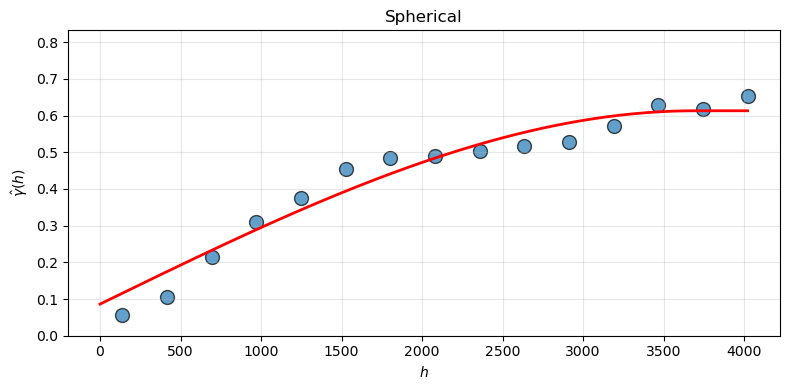

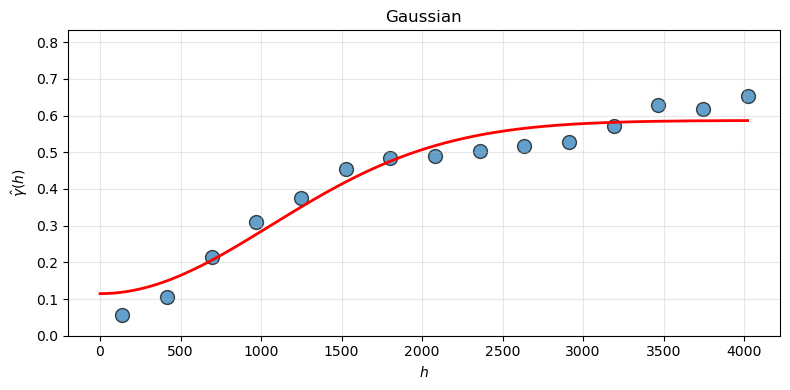

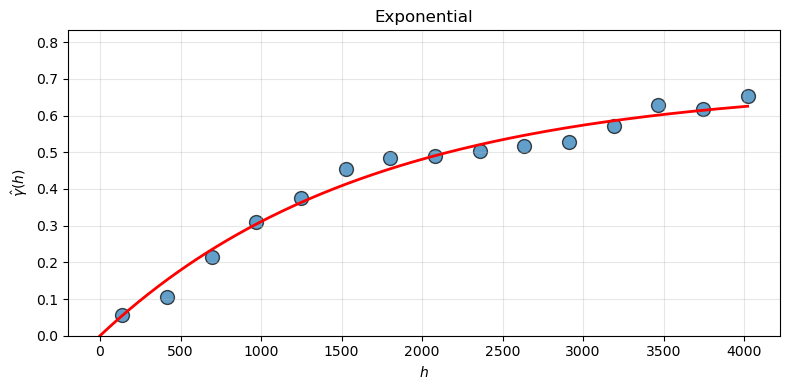

In [10]:
def plot_variogram_curve(lag_centers, gamma_hat, n_pairs,
                          model_func, popt,
                          title="Curve"):
    plt.figure(figsize=(8, 4))
    
    plt.scatter(lag_centers, gamma_hat, s=100, edgecolor='k', alpha=0.7)
    h_smooth = np.linspace(0.01, lag_centers.max(), 200)
    plt.plot(h_smooth, model_func(h_smooth, *popt), linewidth = 2, c = "red")
    
    plt.ylabel(r'$\hat{\gamma}(h)$')
    plt.xlabel(r'$h$')
    plt.title(title)
    plt.ylim(0, np.max(gamma_hat) + np.std(gamma_hat))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_variogram_curve(lag_centers, gamma_hat, n_pairs,
                      spherical_model, sph_variables,
                      title="Spherical")
plot_variogram_curve(lag_centers, gamma_hat, n_pairs,
                      gaussian_model, gaus_variables,
                      title="Gaussian")
plot_variogram_curve(lag_centers, gamma_hat, n_pairs,
                      exponential_model, exp_variables,
                      title="Exponential")

In [11]:
def variogram_residuals_r2(model_function, popt, lag_centers, gamma_hat, n_pairs):
    
    valid = n_pairs > 0
    h = lag_centers[valid]
    g_obs = gamma_hat[valid]
    w = n_pairs[valid]
    
    g_pred = model_function(h, *popt)
    residuals = g_obs - g_pred
    
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((g_obs - np.mean(g_obs))**2)
    r2 = 1 - ss_res / ss_tot
    
    weighted_mean = np.average(g_obs, weights=w)
    ss_res_w = np.sum(w * residuals**2)
    ss_tot_w = np.sum(w * (g_obs - weighted_mean)**2)
    weighted_r2 = 1 - ss_res_w / ss_tot_w
    
    return residuals, r2, weighted_r2

sph_residuals, _, sph_weighted_r2 = variogram_residuals_r2(spherical_model, sph_variables, lag_centers, gamma_hat, n_pairs)
exp_residuals, _, exp_weighted_r2 = variogram_residuals_r2(exponential_model, exp_variables, lag_centers, gamma_hat, n_pairs)
gaus_residuals, _, gaus_weighted_r2 = variogram_residuals_r2(gaussian_model, gaus_variables, lag_centers, gamma_hat, n_pairs)

print("Model Results ----------------\n")
print(f"Spherical Model RMSE: {np.sqrt(np.mean(sph_residuals**2)):.3f}, R2: {sph_weighted_r2:.3f}")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals**2)):.3f}, R2: {exp_weighted_r2:.3f}")
print(f"Gaussian Model RMSE: {np.sqrt(np.mean(gaus_residuals**2)):.3f}, R2: {gaus_weighted_r2:.3f}")

Model Results ----------------

Spherical Model RMSE: 0.039, R2: 0.936
Exponential Model RMSE: 0.026, R2: 0.968
Gaussian Model RMSE: 0.040, R2: 0.928


$$
\begin{bmatrix}
    \Gamma & 1 \\
    1^{T} & 0
\end{bmatrix} \begin{bmatrix}
    \lambda \\
    m
\end{bmatrix} = \begin{bmatrix} \gamma_{x} \\ 1 \end{bmatrix}
$$

In [12]:
def build_gamma_matrix(dist_matrix, model_function, popt):

    Gamma = model_function(dist_matrix, *popt)
    np.fill_diagonal(Gamma, 0)
    return Gamma

def build_krigging_system(Gamma):

    n = Gamma.shape[0]
    A = np.zeros((n + 1, n + 1))
    A[:n, :n] = Gamma
    A[:n, n] = 1
    A[n, :n] = 1
    A[n, n] = 0

    return A

def ordinary_kriging_predict(sX_lan, sX_lat, sample_long, sample_lat, z,
                            model_function, popt, A_inv = None, A = None):

    n = len(z)

    long_rad_0, lat_rad_0 = np.radians(sX_long), np.radians(sX_lat)
    long_rad_s, lat_rad_s = np.radians(sample_long), np.radians(sample_lat)

    dlat = lat_rad_s - lat_rad_0
    dlong = long_rad_s - long_rad_0

    a = np.sin(dlat / 2)**2 + np.cos(lat_rad_0) * np.cos(lat_rad_s) * np.sin(dlong / 2)**2
    h0 = 6371.0 * 2 * np.arcsin(np.sqrt(a))

    gamma_0 = model_function(h0, *popt)

    rhs = np.append(gamma_0, 1)

    if A_inv is not None:

        weights_m = A_inv @ rhs

    else:

        weights_m = np.linalg.solve(A, rhs)

    lamda_value = weights_m[:n]
    m = weights_m[n]

    z_pred = np.sum(lambda_value * z)
    kriging_variance = np.sum(lambda_value * gamma_0) + m

    return z_pred, kriging_variange

In [13]:
africa = gpd.read_file("..\MainlandAfrica.gpkg")
africa = africa.to_crs("EPSG:4326")

minx, miny, maxx, maxy = africa.total_bounds
krigging_resolution = 0.25

grid_long = np.arange(minx, maxx, krigging_resolution)
grid_lat = np.arange(miny, maxy, krigging_resolution)
grid_long_mesh, grid_lat_mesh = np.meshgrid(grid_long, grid_lat)

long_flat = grid_long_mesh.ravel()
lat_flat = grid_lat_mesh.ravel()

points = gpd.GeoSeries([Point(x, y) for x, y in zip(long_flat, lat_flat)], crs="EPSG:4326")
africa_union = africa.union_all()
inside_mask = points.within(africa_union).values

print(f"Grid points total: {len(long_flat)}, inside Africa: {inside_mask.sum()}")

Grid points total: 79764, inside Africa: 39824


In [14]:
def krige_grid(long_pred, lat_pred, sample_long, sample_lat, z, model_function, popt, A_inv):

    n = len(z)
    m = len(long_pred)
    z_pred = np.full(m, np.nan)
    krig_var = np.full(m, np.nan)

    long_rad_s = np.radians(sample_long)
    lat_rad_s = np.radians(sample_lat)
    R = 6371.0

    for i in range(m):
        
        long_rad_0 = np.radians(long_pred[i])
        lat_rad_0 = np.radians(lat_pred[i])

        dlat = lat_rad_s - lat_rad_0
        dlong = long_rad_s - long_rad_0
        a = np.sin(dlat / 2)**2 + np.cos(lat_rad_0) * np.cos(lat_rad_s) * np.sin(dlong / 2)**2
        h0 = R * 2 * np.arcsin(np.sqrt(a))

        gamma_0 = model_function(h0, *popt)
        rhs = np.append(gamma_0, 1)
        weights_m = A_inv @ rhs

        lam = weights_m[:n]
        mlag = weights_m[n]

        z_pred[i] = np.sum(lam * z)
        krig_var[i] = np.sum(lam * gamma_0) + mlag

        #if i % 500 == 0:
        #    print(f"  {i}/{m} predicted...")

    return z_pred, krig_var

In [15]:
Gamma = build_gamma_matrix(distance_matrix, exponential_model, exp_variables)
A = build_krigging_system(Gamma)
A_inv = np.linalg.inv(A)

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

z_pred_inside, krig_var_inside = krige_grid(
    long_inside, lat_inside, longitude, latitude, sin_phi,
    exponential_model, exp_variables, A_inv
)

In [16]:
nodata_value = -9999.0
z_full = np.full(long_flat.shape, nodata_value)
z_full[inside_mask] = z_pred_inside

z_raster = z_full.reshape(grid_long_mesh.shape)
z_raster = np.flipud(z_raster)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

with rasterio.open(
    "Krigging Phi/sin_TempPhi1_kriged.tif",
    "w",
    driver="GTiff",
    height=z_raster.shape[0],
    width=z_raster.shape[1],
    count=1,
    dtype=z_raster.dtype,
    crs="EPSG:4326",
    transform=transform,
    nodata=nodata_value,
) as dst:
    dst.write(z_raster, 1)

print("Raster written: sin_TempPhi1_kriged.tif")

Raster written: sin_TempPhi1_kriged.tif


# Cosine Counterpart

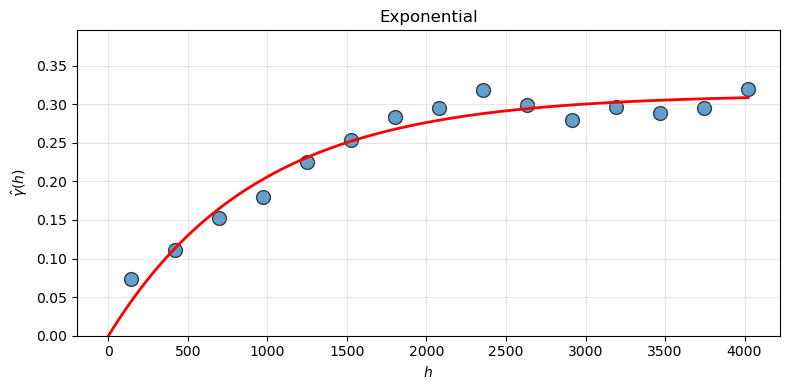

Model Results ----------------

Exponential Model RMSE: 0.017, R2: 0.929


In [17]:
cos_phi = np.cos(data["TempPhi1"].values)

lag_centers_cos, gamma_hat_cos, n_pairs_cos = empirical_variogram(distance_matrix, cos_phi, n_bins = 15)
exp_variables_cos, exp_cov_cos = fit_variogram_model(exponential_model, lag_centers_cos, gamma_hat_cos, n_pairs_cos)

plot_variogram_curve(lag_centers_cos, gamma_hat_cos, n_pairs_cos,
                      exponential_model, exp_variables_cos,
                      title="Exponential")

exp_residuals_cos, _, exp_weighted_r2_cos = variogram_residuals_r2(exponential_model, exp_variables_cos, lag_centers_cos, gamma_hat_cos, n_pairs_cos)

print("Model Results ----------------\n")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_cos**2)):.3f}, R2: {exp_weighted_r2_cos:.3f}")

In [18]:
Gamma_cos = build_gamma_matrix(distance_matrix, exponential_model, exp_variables_cos)
A_cos = build_krigging_system(Gamma_cos)
A_inv_cos = np.linalg.inv(A_cos)

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

z_pred_inside_cos, krig_var_inside_cos = krige_grid(
    long_inside, lat_inside, longitude, latitude, cos_phi,
    exponential_model, exp_variables_cos, A_inv_cos
)

In [19]:
nodata_value = -9999.0
z_full_cos = np.full(long_flat.shape, nodata_value)
z_full_cos[inside_mask] = z_pred_inside_cos

z_raster_cos = z_full_cos.reshape(grid_long_mesh.shape)
z_raster_cos = np.flipud(z_raster_cos)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

with rasterio.open(
    "Krigging Phi/cos_TempPhi1_kriged.tif",
    "w",
    driver = "GTiff",
    height = z_raster_cos.shape[0],
    width = z_raster_cos.shape[1],
    count = 1,
    dtype = z_raster_cos.dtype,
    crs = "EPSG:4326",
    transform = transform,
    nodata = nodata_value,
) as dst:
    dst.write(z_raster_cos, 1)

print("Raster written: cos_TempPhi1_kriged.tif")

Raster written: cos_TempPhi1_kriged.tif


# Combining Cos and Sin to get Phi

In [20]:
with rasterio.open("Krigging Phi/sin_TempPhi1_kriged.tif") as src_sin:
    sin_arr = src_sin.read(1)
    profile = src_sin.profile
    nodata_val = src_sin.nodata

with rasterio.open("Krigging Phi/cos_TempPhi1_kriged.tif") as src_cos:
    cos_arr = src_cos.read(1)

assert sin_arr.shape == cos_arr.shape, "Raster dimensions don't match!"

valid_mask = (sin_arr != nodata_val) & (cos_arr != nodata_val)

phi_arr = np.full(sin_arr.shape, nodata_val, dtype=np.float64)

phi_valid = np.arctan2(sin_arr[valid_mask], cos_arr[valid_mask])
phi_valid = np.mod(phi_valid, 2 * np.pi)

phi_arr[valid_mask] = phi_valid

profile.update(dtype = rasterio.float64, nodata = nodata_val)

with rasterio.open("Krigging Phi/TempPhi1.tif", "w", **profile) as dst:
    dst.write(phi_arr, 1)

print("Phase raster written: TempPhi1.tif")

Phase raster written: TempPhi1.tif


# Get Maps for Temp2, Prec1 and Prec2

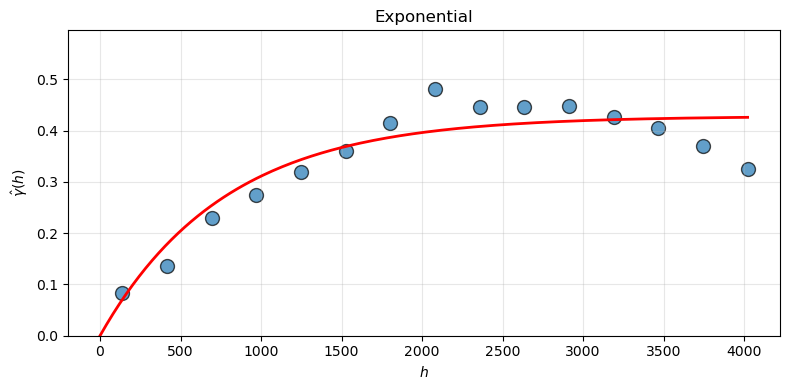

Model Results ----------------

Exponential Model RMSE: 0.044, R2: 0.758
Raster written: cos_TempPhi2_kriged.tif


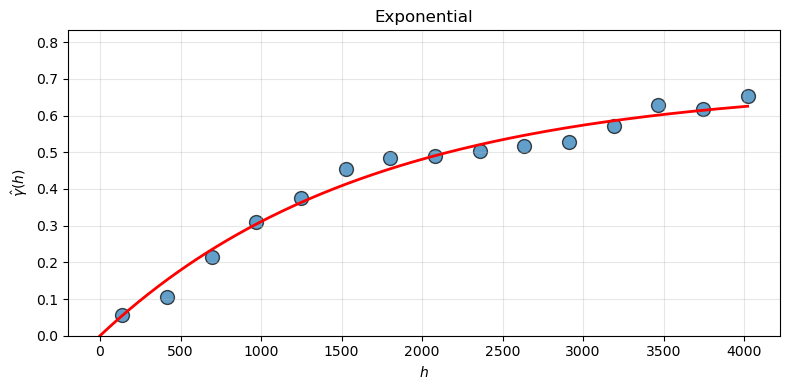

Model Results ----------------

Exponential Model RMSE: 0.026, R2: 0.968
Raster written: sin_TempPhi2_kriged.tif
Phase raster written: TempPhi2.tif


In [21]:
sin_phi_2 = np.sin(data["TempPhi2"].values)
cos_phi_2 = np.cos(data["TempPhi2"].values)

lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2 = empirical_variogram(distance_matrix, cos_phi_2, n_bins = 15)
exp_variables_cos_2, exp_cov_cos_2 = fit_variogram_model(exponential_model, lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2)

plot_variogram_curve(lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2,
                      exponential_model, exp_variables_cos_2,
                      title="Exponential")

exp_residuals_cos_2, _, exp_weighted_r2_cos_2 = variogram_residuals_r2(exponential_model, exp_variables_cos_2, lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2)

print("Model Results ----------------\n")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_cos_2**2)):.3f}, R2: {exp_weighted_r2_cos_2:.3f}")

Gamma_cos_2 = build_gamma_matrix(distance_matrix, exponential_model, exp_variables_cos_2)
A_cos_2 = build_krigging_system(Gamma_cos_2)
A_inv_cos_2 = np.linalg.inv(A_cos_2)

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

z_pred_inside_cos_2, krig_var_inside_cos_2 = krige_grid(
    long_inside, lat_inside, longitude, latitude, cos_phi_2,
    exponential_model, exp_variables_cos_2, A_inv_cos_2
)

nodata_value = -9999.0
z_full_cos_2 = np.full(long_flat.shape, nodata_value)
z_full_cos_2[inside_mask] = z_pred_inside_cos_2

z_raster_cos_2 = z_full_cos_2.reshape(grid_long_mesh.shape)
z_raster_cos_2 = np.flipud(z_raster_cos_2)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

with rasterio.open(
    "Krigging Phi/cos_TempPhi2_kriged.tif",
    "w",
    driver = "GTiff",
    height = z_raster_cos_2.shape[0],
    width = z_raster_cos_2.shape[1],
    count = 1,
    dtype = z_raster_cos_2.dtype,
    crs = "EPSG:4326",
    transform = transform,
    nodata = nodata_value,
) as dst:
    dst.write(z_raster_cos_2, 1)

print("Raster written: cos_TempPhi2_kriged.tif")

lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2 = empirical_variogram(distance_matrix, sin_phi_2, n_bins = 15)
exp_variables_sin_2, exp_cov_sin_2 = fit_variogram_model(exponential_model, lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2)

plot_variogram_curve(lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2,
                      exponential_model, exp_variables_sin_2,
                      title="Exponential")

exp_residuals_sin_2, _, exp_weighted_r2_sin_2 = variogram_residuals_r2(exponential_model, exp_variables_sin_2, lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2)

print("Model Results ----------------\n")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_sin_2**2)):.3f}, R2: {exp_weighted_r2_sin_2:.3f}")

Gamma_sin_2 = build_gamma_matrix(distance_matrix, exponential_model, exp_variables_sin_2)
A_sin_2 = build_krigging_system(Gamma_sin_2)
A_inv_sin_2 = np.linalg.inv(A_sin_2)

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

z_pred_inside_sin_2, krig_var_inside_sin_2 = krige_grid(
    long_inside, lat_inside, longitude, latitude, sin_phi_2,
    exponential_model, exp_variables_sin_2, A_inv_sin_2
)

nodata_value = -9999.0
z_full_sin_2 = np.full(long_flat.shape, nodata_value)
z_full_sin_2[inside_mask] = z_pred_inside_sin_2

z_raster_sin_2 = z_full_sin_2.reshape(grid_long_mesh.shape)
z_raster_sin_2 = np.flipud(z_raster_sin_2)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

with rasterio.open(
    "Krigging Phi/sin_TempPhi2_kriged.tif",
    "w",
    driver = "GTiff",
    height = z_raster_sin_2.shape[0],
    width = z_raster_sin_2.shape[1],
    count = 1,
    dtype = z_raster_sin_2.dtype,
    crs = "EPSG:4326",
    transform = transform,
    nodata = nodata_value,
) as dst:
    dst.write(z_raster_sin_2, 1)

print("Raster written: sin_TempPhi2_kriged.tif")

with rasterio.open("Krigging Phi/sin_TempPhi2_kriged.tif") as src_sin:
    sin_arr = src_sin.read(1)
    profile = src_sin.profile
    nodata_val = src_sin.nodata

with rasterio.open("Krigging Phi/cos_TempPhi2_kriged.tif") as src_cos_2:
    cos_arr = src_cos_2.read(1)

assert sin_arr.shape == cos_arr.shape, "Raster dimensions don't match!"

valid_mask = (sin_arr != nodata_val) & (cos_arr != nodata_val)

phi_arr = np.full(sin_arr.shape, nodata_val, dtype=np.float64)

phi_valid = np.arctan2(sin_arr[valid_mask], cos_arr[valid_mask])
phi_valid = np.mod(phi_valid, 2 * np.pi)

phi_arr[valid_mask] = phi_valid

profile.update(dtype = rasterio.float64, nodata = nodata_val)

with rasterio.open("Krigging Phi/TempPhi2.tif", "w", **profile) as dst:
    dst.write(phi_arr, 1)

print("Phase raster written: TempPhi2.tif")

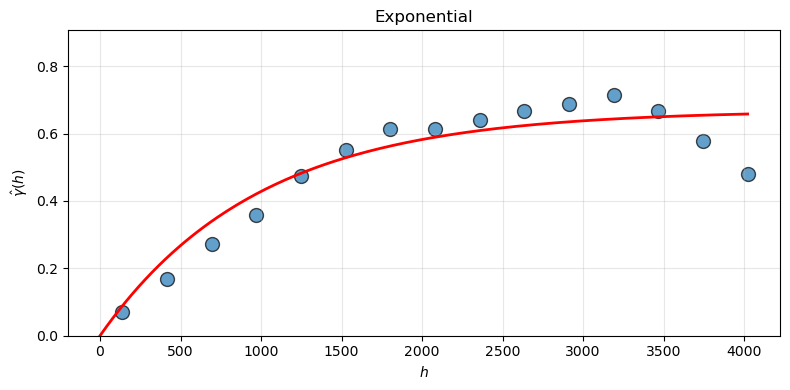

Model Results ----------------

Exponential Model RMSE: 0.066, R2: 0.819
Raster written: cos_PrecPhi2_kriged.tif


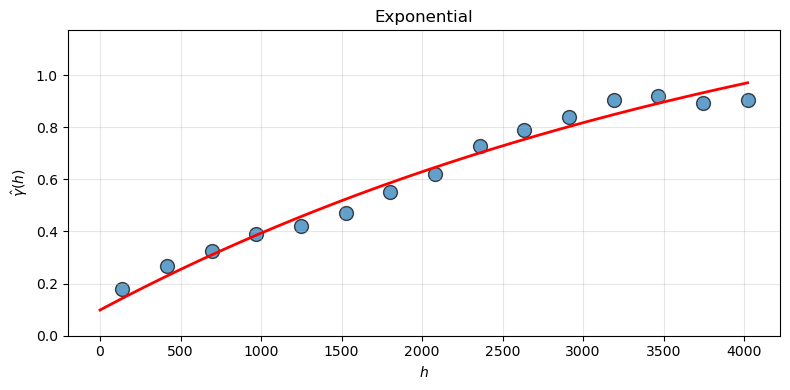

Model Results ----------------

Exponential Model RMSE: 0.038, R2: 0.970
Raster written: sin_PrecPhi2_kriged.tif
Phase raster written: PrecPhi2.tif


In [22]:
sin_phi_2 = np.sin(data["PrecPhi2"].values)
cos_phi_2 = np.cos(data["PrecPhi2"].values)

lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2 = empirical_variogram(distance_matrix, cos_phi_2, n_bins = 15)
exp_variables_cos_2, exp_cov_cos_2 = fit_variogram_model(exponential_model, lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2)

plot_variogram_curve(lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2,
                      exponential_model, exp_variables_cos_2,
                      title="Exponential")

exp_residuals_cos_2, _, exp_weighted_r2_cos_2 = variogram_residuals_r2(exponential_model, exp_variables_cos_2, lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2)

print("Model Results ----------------\n")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_cos_2**2)):.3f}, R2: {exp_weighted_r2_cos_2:.3f}")

Gamma_cos_2 = build_gamma_matrix(distance_matrix, exponential_model, exp_variables_cos_2)
A_cos_2 = build_krigging_system(Gamma_cos_2)
A_inv_cos_2 = np.linalg.inv(A_cos_2)

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

z_pred_inside_cos_2, krig_var_inside_cos_2 = krige_grid(
    long_inside, lat_inside, longitude, latitude, cos_phi_2,
    exponential_model, exp_variables_cos_2, A_inv_cos_2
)

nodata_value = -9999.0
z_full_cos_2 = np.full(long_flat.shape, nodata_value)
z_full_cos_2[inside_mask] = z_pred_inside_cos_2

z_raster_cos_2 = z_full_cos_2.reshape(grid_long_mesh.shape)
z_raster_cos_2 = np.flipud(z_raster_cos_2)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

with rasterio.open(
    "Krigging Phi/cos_PrecPhi2_kriged.tif",
    "w",
    driver = "GTiff",
    height = z_raster_cos_2.shape[0],
    width = z_raster_cos_2.shape[1],
    count = 1,
    dtype = z_raster_cos_2.dtype,
    crs = "EPSG:4326",
    transform = transform,
    nodata = nodata_value,
) as dst:
    dst.write(z_raster_cos_2, 1)

print("Raster written: cos_PrecPhi2_kriged.tif")

lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2 = empirical_variogram(distance_matrix, sin_phi_2, n_bins = 15)
exp_variables_sin_2, exp_cov_sin_2 = fit_variogram_model(exponential_model, lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2)

plot_variogram_curve(lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2,
                      exponential_model, exp_variables_sin_2,
                      title="Exponential")

exp_residuals_sin_2, _, exp_weighted_r2_sin_2 = variogram_residuals_r2(exponential_model, exp_variables_sin_2, lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2)

print("Model Results ----------------\n")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_sin_2**2)):.3f}, R2: {exp_weighted_r2_sin_2:.3f}")

Gamma_sin_2 = build_gamma_matrix(distance_matrix, exponential_model, exp_variables_sin_2)
A_sin_2 = build_krigging_system(Gamma_sin_2)
A_inv_sin_2 = np.linalg.inv(A_sin_2)

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

z_pred_inside_sin_2, krig_var_inside_sin_2 = krige_grid(
    long_inside, lat_inside, longitude, latitude, sin_phi_2,
    exponential_model, exp_variables_sin_2, A_inv_sin_2
)

nodata_value = -9999.0
z_full_sin_2 = np.full(long_flat.shape, nodata_value)
z_full_sin_2[inside_mask] = z_pred_inside_sin_2

z_raster_sin_2 = z_full_sin_2.reshape(grid_long_mesh.shape)
z_raster_sin_2 = np.flipud(z_raster_sin_2)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

with rasterio.open(
    "Krigging Phi/sin_PrecPhi2_kriged.tif",
    "w",
    driver = "GTiff",
    height = z_raster_sin_2.shape[0],
    width = z_raster_sin_2.shape[1],
    count = 1,
    dtype = z_raster_sin_2.dtype,
    crs = "EPSG:4326",
    transform = transform,
    nodata = nodata_value,
) as dst:
    dst.write(z_raster_sin_2, 1)

print("Raster written: sin_PrecPhi2_kriged.tif")

with rasterio.open("Krigging Phi/sin_PrecPhi2_kriged.tif") as src_sin:
    sin_arr = src_sin.read(1)
    profile = src_sin.profile
    nodata_val = src_sin.nodata

with rasterio.open("Krigging Phi/cos_PrecPhi2_kriged.tif") as src_cos_2:
    cos_arr = src_cos_2.read(1)

assert sin_arr.shape == cos_arr.shape, "Raster dimensions don't match!"

valid_mask = (sin_arr != nodata_val) & (cos_arr != nodata_val)

phi_arr = np.full(sin_arr.shape, nodata_val, dtype=np.float64)

phi_valid = np.arctan2(sin_arr[valid_mask], cos_arr[valid_mask])
phi_valid = np.mod(phi_valid, 2 * np.pi)

phi_arr[valid_mask] = phi_valid

profile.update(dtype = rasterio.float64, nodata = nodata_val)

with rasterio.open("Krigging Phi/PrecPhi2.tif", "w", **profile) as dst:
    dst.write(phi_arr, 1)

print("Phase raster written: PrecPhi2.tif")

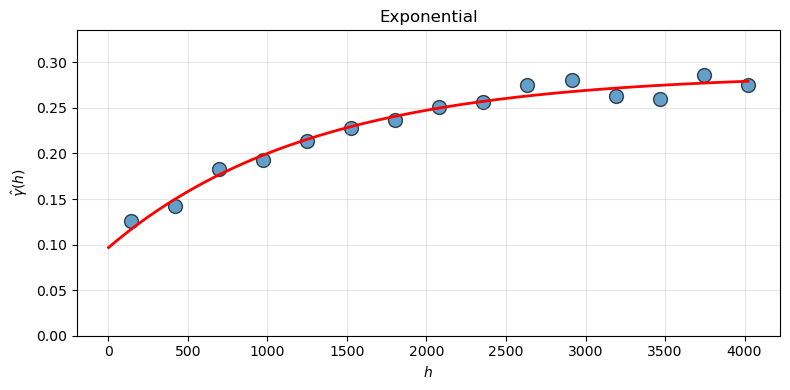

Model Results ----------------

Exponential Model RMSE: 0.008, R2: 0.957
Raster written: cos_PrecPhi1_kriged.tif


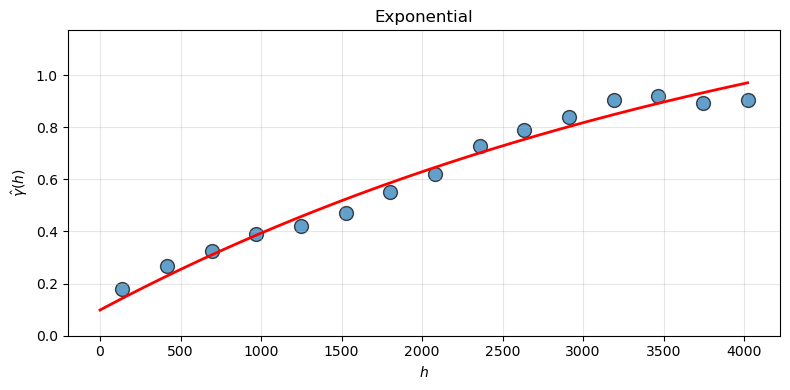

Model Results ----------------

Exponential Model RMSE: 0.038, R2: 0.970
Raster written: sin_PrecPhi1_kriged.tif
Phase raster written: PrecPhi1.tif


In [23]:
sin_phi_2 = np.sin(data["PrecPhi1"].values)
cos_phi_2 = np.cos(data["PrecPhi1"].values)

lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2 = empirical_variogram(distance_matrix, cos_phi_2, n_bins = 15)
exp_variables_cos_2, exp_cov_cos_2 = fit_variogram_model(exponential_model, lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2)

plot_variogram_curve(lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2,
                      exponential_model, exp_variables_cos_2,
                      title="Exponential")

exp_residuals_cos_2, _, exp_weighted_r2_cos_2 = variogram_residuals_r2(exponential_model, exp_variables_cos_2, lag_centers_cos_2, gamma_hat_cos_2, n_pairs_cos_2)

print("Model Results ----------------\n")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_cos_2**2)):.3f}, R2: {exp_weighted_r2_cos_2:.3f}")

Gamma_cos_2 = build_gamma_matrix(distance_matrix, exponential_model, exp_variables_cos_2)
A_cos_2 = build_krigging_system(Gamma_cos_2)
A_inv_cos_2 = np.linalg.inv(A_cos_2)

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

z_pred_inside_cos_2, krig_var_inside_cos_2 = krige_grid(
    long_inside, lat_inside, longitude, latitude, cos_phi_2,
    exponential_model, exp_variables_cos_2, A_inv_cos_2
)

nodata_value = -9999.0
z_full_cos_2 = np.full(long_flat.shape, nodata_value)
z_full_cos_2[inside_mask] = z_pred_inside_cos_2

z_raster_cos_2 = z_full_cos_2.reshape(grid_long_mesh.shape)
z_raster_cos_2 = np.flipud(z_raster_cos_2)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

with rasterio.open(
    "Krigging Phi/cos_PrecPhi1_kriged.tif",
    "w",
    driver = "GTiff",
    height = z_raster_cos_2.shape[0],
    width = z_raster_cos_2.shape[1],
    count = 1,
    dtype = z_raster_cos_2.dtype,
    crs = "EPSG:4326",
    transform = transform,
    nodata = nodata_value,
) as dst:
    dst.write(z_raster_cos_2, 1)

print("Raster written: cos_PrecPhi1_kriged.tif")

lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2 = empirical_variogram(distance_matrix, sin_phi_2, n_bins = 15)
exp_variables_sin_2, exp_cov_sin_2 = fit_variogram_model(exponential_model, lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2)

plot_variogram_curve(lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2,
                      exponential_model, exp_variables_sin_2,
                      title="Exponential")

exp_residuals_sin_2, _, exp_weighted_r2_sin_2 = variogram_residuals_r2(exponential_model, exp_variables_sin_2, lag_centers_sin_2, gamma_hat_sin_2, n_pairs_sin_2)

print("Model Results ----------------\n")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_sin_2**2)):.3f}, R2: {exp_weighted_r2_sin_2:.3f}")

Gamma_sin_2 = build_gamma_matrix(distance_matrix, exponential_model, exp_variables_sin_2)
A_sin_2 = build_krigging_system(Gamma_sin_2)
A_inv_sin_2 = np.linalg.inv(A_sin_2)

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

z_pred_inside_sin_2, krig_var_inside_sin_2 = krige_grid(
    long_inside, lat_inside, longitude, latitude, sin_phi_2,
    exponential_model, exp_variables_sin_2, A_inv_sin_2
)

nodata_value = -9999.0
z_full_sin_2 = np.full(long_flat.shape, nodata_value)
z_full_sin_2[inside_mask] = z_pred_inside_sin_2

z_raster_sin_2 = z_full_sin_2.reshape(grid_long_mesh.shape)
z_raster_sin_2 = np.flipud(z_raster_sin_2)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

with rasterio.open(
    "Krigging Phi/sin_PrecPhi1_kriged.tif",
    "w",
    driver = "GTiff",
    height = z_raster_sin_2.shape[0],
    width = z_raster_sin_2.shape[1],
    count = 1,
    dtype = z_raster_sin_2.dtype,
    crs = "EPSG:4326",
    transform = transform,
    nodata = nodata_value,
) as dst:
    dst.write(z_raster_sin_2, 1)

print("Raster written: sin_PrecPhi1_kriged.tif")

with rasterio.open("Krigging Phi/sin_PrecPhi1_kriged.tif") as src_sin:
    sin_arr = src_sin.read(1)
    profile = src_sin.profile
    nodata_val = src_sin.nodata

with rasterio.open("Krigging Phi/cos_PrecPhi1_kriged.tif") as src_cos_2:
    cos_arr = src_cos_2.read(1)

assert sin_arr.shape == cos_arr.shape, "Raster dimensions don't match!"

valid_mask = (sin_arr != nodata_val) & (cos_arr != nodata_val)

phi_arr = np.full(sin_arr.shape, nodata_val, dtype=np.float64)

phi_valid = np.arctan2(sin_arr[valid_mask], cos_arr[valid_mask])
phi_valid = np.mod(phi_valid, 2 * np.pi)

phi_arr[valid_mask] = phi_valid

profile.update(dtype = rasterio.float64, nodata = nodata_val)

with rasterio.open("Krigging Phi/PrecPhi1.tif", "w", **profile) as dst:
    dst.write(phi_arr, 1)

print("Phase raster written: PrecPhi1.tif")

# Extension for Predicting over Time

Now we have the baseline for $\phi$ at present, we need to find a way to extrapolate to other times where different variables regarding the earths tilt and orbit effect the seasons.

Ordinary krigging assumes a constant, unkown mean across the whole domain. While this is fine for the baseline, when we make predictions for the same location at different points in geological time we have to consider underlying orbital forcing differences. A constant $\mu$ therefore does not capture this and needs to shift as a function of orbital state. Instead of

$$
Z(s) = \mu + \epsilon (s)
$$

We now model

$$
Z(s,t) = \beta_{0} + \beta_{1} \text{obl}(t) + \beta_{2} \text{prec}(t) + \beta_{3} \text{ecc}(t) + \epsilon(s,t)
$$

Where $t$ is now the time dependent variable, obl is the obliquity, prec is the precession, and ecc the eccentricity of the earths orbit. What we are predicting therefore in the krigging model are the residuals after removing the orbitally-driven global shifts in $\mu$.

The workflow becomes;

 - **Fit the trend** via OLS regression, $Z(s_{i},t) = X (s_{i}, t) \beta + \epsilon_{i}$, where $X$ is the design matrix of orbital vocariates.
 - **Compute residuals**, $r_{i} = Z(s_{i},t) - X(s_{i}, t) \hat{\beta}$
 - **Fit a variogram to the residuals**
 - **Krige the residuals**
 - **Add back the trend at prediction time**; $\hat{Z}(s_{x}, t) = X(s_{x}, t) \hat{\beta} + \hat{r}(s_{x})$

We get the data necessary from **Laskar et al. 2004**'s solution. While there is an improved model, the last 45 Ma are practically identical across the solutions so we will stick with La2004. We will use the **INSOLN.LA2004.BTL.ASC** file which is more accurate for the last 50 Ma.

This file contains columns $t$, which is in Ka, $e$ eccentricity, $\varepsilon$ obliquity in radians, $\bar{\pi}$ or $\varpi$ which is the longitude of perihelion in radians.

In [24]:
from io import StringIO

def load_la2004(filepath):

    with open(filepath, "r") as f:
        lines = f.readlines()
    
    cleaned_lines = [line.replace("D+", "E+").replace("D-", "E-") for line in lines]
    
    data_str = "".join(cleaned_lines)
    
    df = pd.read_csv(
        StringIO(data_str),
        delim_whitespace=True,
        header=None,
        names=["t", "eccentricity", "obliquity_rad", "pibar_rad"]
    )
    
    df["obliquity_deg"] = np.degrees(df["obliquity_rad"])
    df["climatic_precession"] = df["eccentricity"] * np.sin(df["pibar_rad"])
    
    return df

la2004 = load_la2004("./La2004 Data/La2004/INSOLN.LA2004.BTL.ASC")

print(la2004.head())
print(f"\nObliquity at t=0: {la2004.loc[la2004['t']==0, 'obliquity_deg'].values[0]:.4f} degrees")


     t  eccentricity  obliquity_rad  pibar_rad  obliquity_deg  \
0  0.0      0.016702       0.409093   1.796257      23.439291   
1 -1.0      0.017161       0.411353   1.497928      23.568790   
2 -2.0      0.017497       0.413555   1.200024      23.694943   
3 -3.0      0.017846       0.415639   0.903494      23.814370   
4 -4.0      0.018211       0.417555   0.611381      23.924127   

   climatic_precession  
0             0.016280  
1             0.017116  
2             0.016308  
3             0.014018  
4             0.010453  

Obliquity at t=0: 23.4393 degrees


C:\Users\l.courtenay\AppData\Local\Temp\ipykernel_39900\2852637340.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


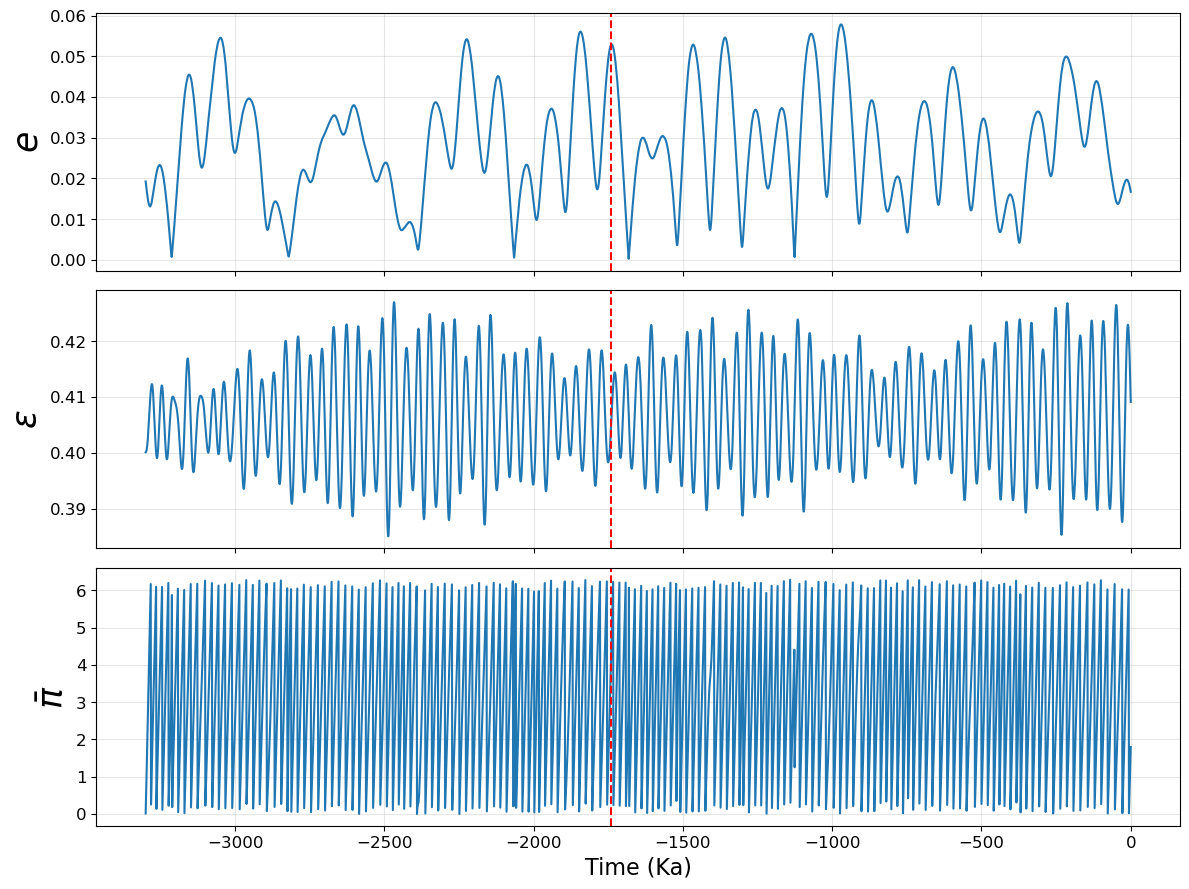

In [53]:
la2004_recent = la2004[la2004["t"] >= -3300].copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

variables = {
    "eccentricity": r'$e$',
    "obliquity_rad": r'$\varepsilon$',
    "pibar_rad": r'$\bar{\pi}$',
}

target_age = -1740  # 1.74 Ma

for ax, (col, ylabel) in zip(axes, variables.items()):
    ax.plot(la2004_recent["t"].values, la2004_recent[col].values)
    ax.axvline(target_age, color='red', linestyle='--', linewidth=1.5)
    ax.set_ylabel(ylabel, fontsize=25)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (Ka)", fontsize=16)
plt.tight_layout()
plt.show()



The three variables above tell us different things about the earhts orbit. For frame of reference, in the present day we have $e = 0.0167$, $\varepsilon = 0.4091^{\text{rad}}$, or $23.429^{\circ}$ and $\varpi = 1.7963^{\text{rad}}$. I will be comparing with the earths orbit at $1.74$ Ma for comparison with the emergence of the Acheulean at Konso.

$e$ is eccentricity, and tells us how elliptical the earhts orbit is. $e = 0$ would be a perfect circle, while higher values will express more elongated orbital tendencies. Higher eccentricity means a bigger difference between Earth's closest approach to the Sun (perihelion) and farthest point (aphelion). This variable therefore conditions how much the other cycles matter.

$\varepsilon$ is obliquity, the tilt of the Earth's rotational axis relative to its orbital plane in radians. Higher obliquity means more extreme seasons (hotter summer, colder winter), especially at high latitudes. Near the equator, however, obliquity has less of an impact, therefore it is more common that we work with absolute latitude values to stress its influence as we draw away from the equator.

$\varpi$ is the longitude of perihelion, which describes where in Earth's orbit the seasons fall. Specifically, it tarcks which point of the elliptical orbit corresponds to the Earth's closest approach to the sun.

Climatic precession is then calculated as $e \sin \varpi$. This combined index answers the actual climatically relevant question, is the perihelion currently aligned with northern hemisphere summer or winter? The current data climatic precession is 0.0163. The emergence of the Acheulean corresponds with a unique moment where the precession is -0.05, which means that we have met both a high eccentricity, and $\varpi$ is alligning near $\sin \varpi \approx -1$, which marks a strong precession-driven seaonsal contrast.

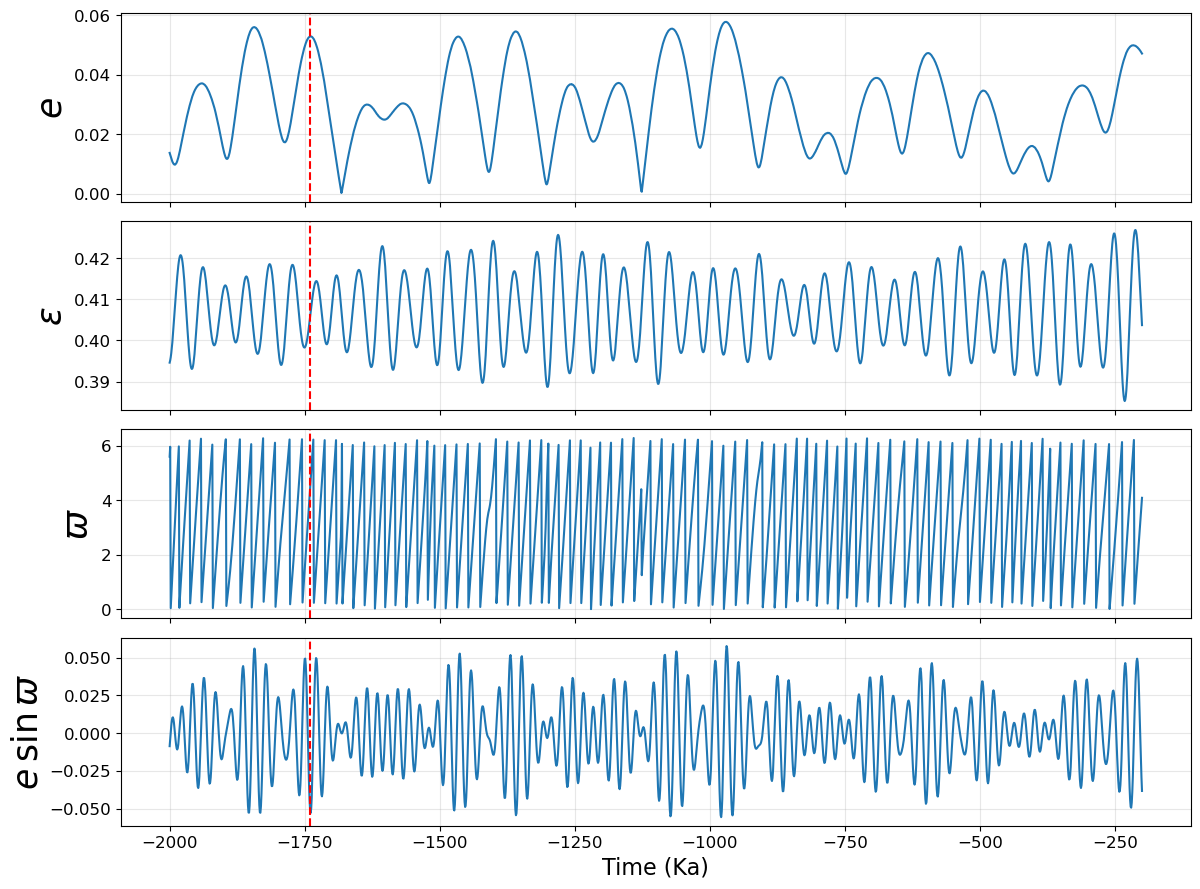

Variables at 1.74 Ma

Eccentricity = [0.05295432]
Obliquity = [23.24410026] degrees
Longitude of Perihelion = [4.43750407] degrees
Cimatic Precession = [-0.05096623]


C:\Users\l.courtenay\AppData\Local\Temp\ipykernel_39900\3751521187.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_data = la2004_recent[la2004["t"] == target_age]


In [26]:
la2004_recent = la2004[(la2004["t"] >= -2000) & (la2004["t"] <= -200)].copy()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

variables = {
    "eccentricity": r'$e$',
    "obliquity_rad": r'$\varepsilon$',
    "pibar_rad": r'$\varpi$',
    "climatic_precession": r"$e \: \sin \varpi$"
}

target_age = -1740  # 1.74 Ma

for ax, (col, ylabel) in zip(axes, variables.items()):
    ax.plot(la2004_recent["t"].values, la2004_recent[col].values)
    ax.axvline(target_age, color='red', linestyle='--', linewidth=1.5)
    ax.set_ylabel(ylabel, fontsize=25)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (Ka)", fontsize=16)
plt.tight_layout()
plt.show()

target_data = la2004_recent[la2004["t"] == target_age]
print(f"Variables at 1.74 Ma\n")
print(f"Eccentricity = {target_data["eccentricity"].values}")
print(f"Obliquity = {target_data["obliquity_deg"].values} degrees")
print(f"Longitude of Perihelion = {target_data["pibar_rad"].values} degrees")
print(f"Cimatic Precession = {target_data["climatic_precession"].values}")

In [27]:
def build_design_matrix(latitude, eccentricity, obliquity, climatic_precession):

    lat_rad = np.radians(latitude)
    n = len(latitude)

    e_arr = np.full(n, eccentricity) if np.isscalar(eccentricity) else eccentricity
    obl_arr = np.full(n, obliquity) if np.isscalar(obliquity) else obliquity
    prec_arr = np.full(n, climatic_precession) if np.isscalar(climatic_precession) else climatic_precession

    intercept = np.ones(n)
    prec_lat_interaction = prec_arr * np.sin(lat_rad)
    obl_lat_interaction = obl_arr * np.abs(lat_rad)

    X = np.column_stack([
        intercept, e_arr, obl_arr, prec_arr, prec_lat_interaction, obl_lat_interaction
    ])

    return X

def fit_trend_ols(X, z):

    beta, residuals_ss, rank, singular_values = np.linalg.lstsq(X, z, rcond = None)

    z_fitted = X @ beta
    residuals = z - z_fitted

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((z - np.mean(z))**2)
    r2 = 1 - ss_res / ss_tot

    return beta, z_fitted, residuals, r2

In [28]:
orbital_today = la2004[la2004["t"] == 0].iloc[0]

X = build_design_matrix(
    latitude = latitude,
    eccentricity = orbital_today["eccentricity"],
    obliquity = orbital_today["obliquity_rad"],
    climatic_precession = orbital_today["eccentricity"] * np.sin(orbital_today["pibar_rad"])
)

beta_sin, z_fitted_sin, residuals_sin, r2_sin = fit_trend_ols(X, sin_phi)

print("Fitted coefficients:")
labels = ["intercept", "eccentricity", "obliquity", "precession", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_sin):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_sin:.4f}")

X_cos = X
beta_cos, z_fitted_cos, residuals_cos, r2_cos = fit_trend_ols(X_cos, cos_phi)


Fitted coefficients:
  intercept: -0.64546
  eccentricity: -0.01078
  obliquity: -0.26405
  precession: -0.01051
  precession*sin(lat): 88.82398
  obliquity*|lat|: 4.19424

Trend R²: 0.5329


In [29]:
beta, residuals_ss, rank, sv = np.linalg.lstsq(X, sin_phi, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]} columns")
print(f"Singular values: {sv}")

Rank: 3 out of 6 columns
Singular values: [2.63637292e+01 1.91234831e+00 1.18303969e-01 4.16487579e-16
 3.08559224e-18 4.26227669e-19]


Unfortunately we cannot fit the eccentricity, obliquity and precession values themselves on our data because we do not have enough time depth for validation, so we will have to redesign the model to only consider the intercept with $e \sin \varpi \times \:\sin(\phi)$ and $\varepsilon |\phi|$

In [30]:
def build_design_matrix_v2(latitude, obliquity_rad, climatic_precession):
    
    lat_rad = np.radians(latitude)
    n = len(latitude)

    obl_arr = np.full(n, obliquity_rad) if np.isscalar(obliquity_rad) else obliquity_rad
    prec_arr = np.full(n, climatic_precession) if np.isscalar(climatic_precession) else climatic_precession

    intercept = np.ones(n)
    prec_lat_interaction = prec_arr * np.sin(lat_rad)
    obl_lat_interaction = obl_arr * np.abs(lat_rad)

    X = np.column_stack([intercept, prec_lat_interaction, obl_lat_interaction])
    
    return X

orbital_today = la2004[la2004["t"] == 0].iloc[0]

X = build_design_matrix_v2(
    latitude=latitude,
    obliquity_rad=orbital_today["obliquity_rad"],
    climatic_precession=orbital_today["eccentricity"] * np.sin(orbital_today["pibar_rad"])
)

beta_sin, z_fitted_sin, residuals_sin, r2_sin = fit_trend_ols(X, sin_phi)

print("Fitted coefficients for Sin Phi:")
labels = ["intercept", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_sin):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_sin:.4f}")

beta, residuals_ss, rank, sv = np.linalg.lstsq(X, sin_phi, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]}")

X_cos = X
beta_cos, z_fitted_cos, residuals_cos, r2_cos = fit_trend_ols(X_cos, cos_phi)

print("\n\nFitted coefficients for Cos Phi:")
labels = ["intercept", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_cos):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_cos:.4f}")

beta, residuals_ss, rank, sv = np.linalg.lstsq(X, cos_phi, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]}")

Fitted coefficients for Sin Phi:
  intercept: -0.75384
  precession*sin(lat): 88.82398
  obliquity*|lat|: 4.19424

Trend R²: 0.5329
Rank: 3 out of 3


Fitted coefficients for Cos Phi:
  intercept: -0.13044
  precession*sin(lat): -76.15104
  obliquity*|lat|: 1.23546

Trend R²: 0.4641
Rank: 3 out of 3


Now we proceed to refitting the variogram on the residuals. Instead of using sin_phi and cos_phi to fit the krigging models, we use the residuals:

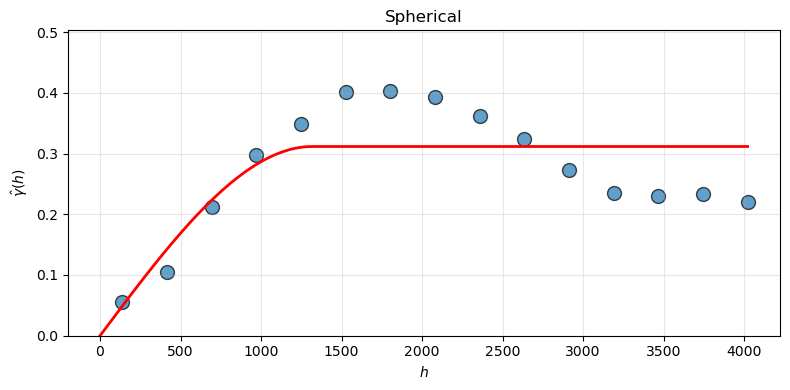

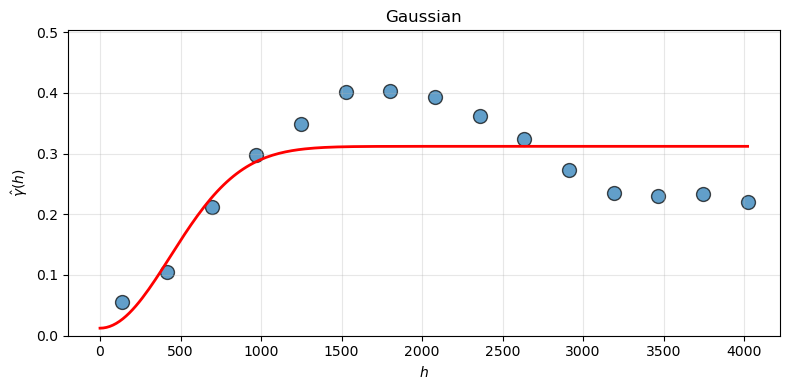

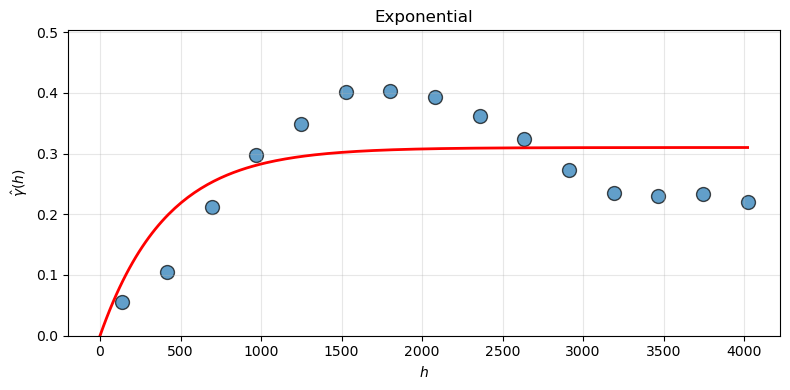

Model Results ----------------

Spherical Model RMSE: 0.062, R2: 0.404
Exponential Model RMSE: 0.069, R2: 0.315
Gaussian Model RMSE: 0.062, R2: 0.404


In [31]:
lag_centers_r, gamma_hat_r, n_pairs_r = empirical_variogram(
    distance_matrix, residuals_sin, n_bins=15
)

gaus_variables_r, gaus_cov_r = fit_variogram_model(gaussian_model, lag_centers_r, gamma_hat_r, n_pairs_r)
sph_variables_r, sph_cov_r = fit_variogram_model(spherical_model, lag_centers_r, gamma_hat_r, n_pairs_r)
exp_variables_r, exp_cov_r = fit_variogram_model(exponential_model, lag_centers_r, gamma_hat_r, n_pairs_r)

plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      spherical_model, sph_variables_r,
                      title="Spherical")
plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      gaussian_model, gaus_variables_r,
                      title="Gaussian")
plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      exponential_model, exp_variables_r,
                      title="Exponential")

sph_residuals_r, _, sph_weighted_r2_r = variogram_residuals_r2(spherical_model, sph_variables_r, lag_centers_r, gamma_hat_r, n_pairs_r)
exp_residuals_r, _, exp_weighted_r2_r = variogram_residuals_r2(exponential_model, exp_variables_r, lag_centers_r, gamma_hat_r, n_pairs_r)
gaus_residuals_r, _, gaus_weighted_r2_r = variogram_residuals_r2(gaussian_model, gaus_variables_r, lag_centers_r, gamma_hat_r, n_pairs_r)

print("Model Results ----------------\n")
print(f"Spherical Model RMSE: {np.sqrt(np.mean(sph_residuals_r**2)):.3f}, R2: {sph_weighted_r2_r:.3f}")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_r**2)):.3f}, R2: {exp_weighted_r2_r:.3f}")
print(f"Gaussian Model RMSE: {np.sqrt(np.mean(gaus_residuals_r**2)):.3f}, R2: {gaus_weighted_r2_r:.3f}")

Residual Sin exponential fit: nugget=0.00000, sill=0.30994, range=410.80 km


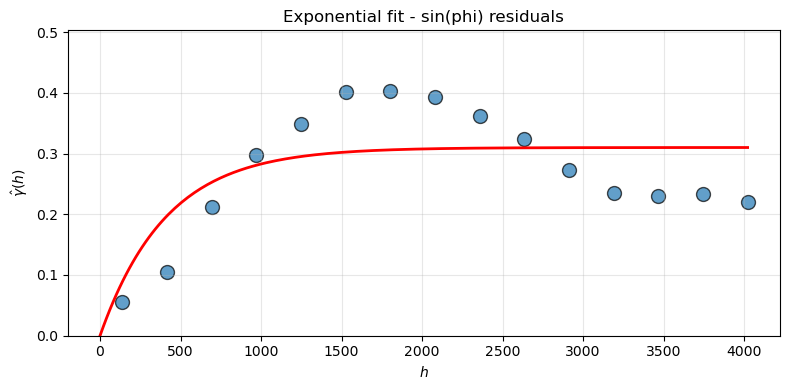

Residual Cos exponential fit: nugget=0.00000, sill=0.18021, range=372.26 km


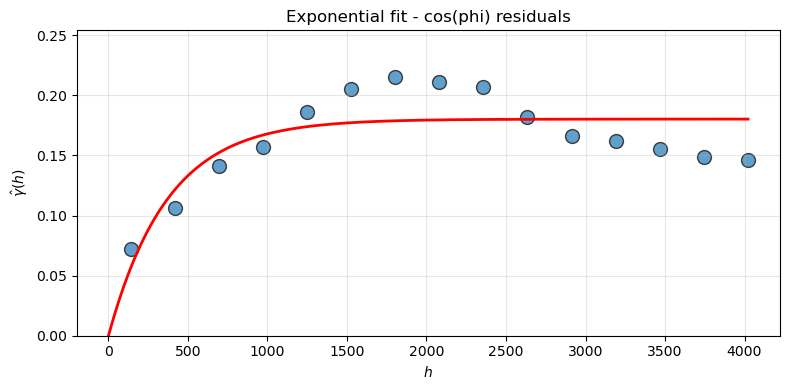

In [32]:
lag_centers_r, gamma_hat_r, n_pairs_r = empirical_variogram(
    distance_matrix, residuals_sin, n_bins=15
)

exp_params_resid, exp_pcov_resid = fit_variogram_model(
    exponential_model, lag_centers_r, gamma_hat_r, n_pairs_r
)

print(f"Residual Sin exponential fit: nugget={exp_params_resid[0]:.5f}, "
      f"sill={exp_params_resid[1]:.5f}, range={exp_params_resid[2]:.2f} km")

plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      exponential_model, exp_params_resid,
                      title="Exponential fit - sin(phi) residuals")

lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos = empirical_variogram(
    distance_matrix, residuals_cos, n_bins=15
)

exp_params_resid_cos, exp_pcov_resid_cos = fit_variogram_model(
    exponential_model, lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos
)

print(f"Residual Cos exponential fit: nugget={exp_params_resid_cos[0]:.5f}, "
      f"sill={exp_params_resid_cos[1]:.5f}, range={exp_params_resid_cos[2]:.2f} km")

plot_variogram_curve(lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos,
                      exponential_model, exp_params_resid_cos,
                      title="Exponential fit - cos(phi) residuals")

In [33]:
Gamma_sin = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid)
A_sin = build_krigging_system(Gamma_sin)
A_inv_sin = np.linalg.inv(A_sin)

Gamma_cos = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid_cos)
A_cos = build_krigging_system(Gamma_cos)
A_inv_cos = np.linalg.inv(A_cos)

resid_sin_pred, resid_sin_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_sin,
    exponential_model, exp_params_resid, A_inv_sin
)

resid_cos_pred, resid_cos_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_cos,
    exponential_model, exp_params_resid_cos, A_inv_cos
)

In [37]:
target_t = -1740

obliquity_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["obliquity_rad"].values[::-1])
ecc_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["eccentricity"].values[::-1])
pibar_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["pibar_rad"].values[::-1])
precession_174 = ecc_174 * np.sin(pibar_174)

print(f"At 1.74 Ma: obliquity={np.degrees(obliquity_174):.4f} deg, "
      f"eccentricity={ecc_174:.5f}, climatic precession={precession_174:.5f}")

lat_inside_rad = np.radians(lat_inside)
trend_sin_174 = (beta_sin[0] +
                  beta_sin[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta_sin[2] * obliquity_174 * np.abs(lat_inside_rad))

trend_cos_174 = (beta_cos[0] +
                  beta_cos[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta_cos[2] * obliquity_174 * np.abs(lat_inside_rad))

sin_pred_174 = trend_sin_174 + resid_sin_pred
cos_pred_174 = trend_cos_174 + resid_cos_pred

phi_pred_174 = np.mod(np.arctan2(sin_pred_174, cos_pred_174), 2*np.pi)

nodata_value = -9999.0

def reassemble_raster(values_inside, inside_mask, grid_shape, nodata_value):
    full = np.full(inside_mask.shape, nodata_value)
    full[inside_mask] = values_inside
    raster = full.reshape(grid_shape)
    raster = np.flipud(raster)  # north-up orientation for GeoTIFF convention
    return raster

sin_raster_174 = reassemble_raster(sin_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)
cos_raster_174 = reassemble_raster(cos_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)
phi_raster_174 = reassemble_raster(phi_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)

total_var_174 = resid_sin_var + resid_cos_var
var_raster_174 = reassemble_raster(total_var_174, inside_mask, grid_long_mesh.shape, nodata_value)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

def write_geotiff(filepath, raster, transform, nodata_value):
    with rasterio.open(
        filepath, "w",
        driver="GTiff",
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=raster.dtype,
        crs="EPSG:4326",
        transform=transform,
        nodata=nodata_value,
    ) as dst:
        dst.write(raster, 1)
    print(f"Written: {filepath}")

write_geotiff("Krigging Phi/TempPhi_1_74Ma_reconstructed.tif", phi_raster_174, transform, nodata_value)
write_geotiff("Krigging Phi/sin_TempPhi_1_74Ma.tif", sin_raster_174, transform, nodata_value)
write_geotiff("Krigging Phi/cos_TempPhi_1_74Ma.tif", cos_raster_174, transform, nodata_value)
#write_geotiff("Krigging Phi/kriging_variance_1.74Ma.tif", var_raster_174, transform, nodata_value)

At 1.74 Ma: obliquity=23.2441 deg, eccentricity=0.05295, climatic precession=-0.05097
Written: Krigging Phi/TempPhi_1_74Ma_reconstructed.tif
Written: Krigging Phi/sin_TempPhi_1_74Ma.tif
Written: Krigging Phi/cos_TempPhi_1_74Ma.tif


# Temp Phi 2

Fitted coefficients for Sin Phi:
  intercept: -0.75384
  precession*sin(lat): 88.82398
  obliquity*|lat|: 4.19424

Trend R²: 0.5329
Rank: 3 out of 3


Fitted coefficients for Cos Phi:
  intercept: -0.02996
  precession*sin(lat): 3.74269
  obliquity*|lat|: 0.91103

Trend R²: 0.0153
Rank: 3 out of 3
Residual Sin exponential fit: nugget=0.00000, sill=0.30994, range=410.80 km


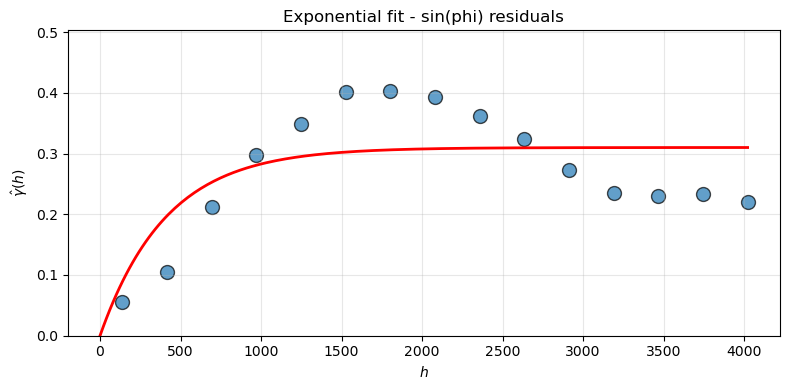

Residual Cos exponential fit: nugget=0.00000, sill=0.43575, range=760.07 km


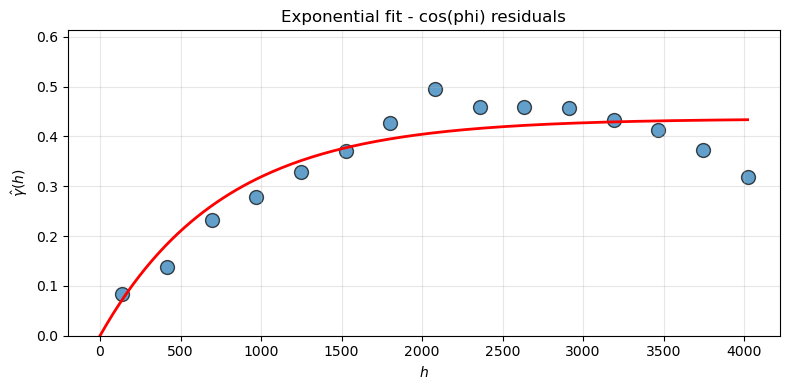

At 1.74 Ma: obliquity=23.2441 deg, eccentricity=0.05295, climatic precession=-0.05097
Written: Krigging Phi/TempPhi2_1_74Ma_reconstructed.tif
Written: Krigging Phi/sin_TempPhi2_1_74Ma.tif
Written: Krigging Phi/cos_TempPhi2_1_74Ma.tif


In [39]:

sin_phi_2 = np.sin(data["TempPhi2"].values)
cos_phi_2 = np.cos(data["TempPhi2"].values)

orbital_today = la2004[la2004["t"] == 0].iloc[0]

X = build_design_matrix_v2(
    latitude=latitude,
    obliquity_rad=orbital_today["obliquity_rad"],
    climatic_precession=orbital_today["eccentricity"] * np.sin(orbital_today["pibar_rad"])
)

beta_sin, z_fitted_sin, residuals_sin, r2_sin = fit_trend_ols(X, sin_phi_2)

print("Fitted coefficients for Sin Phi:")
labels = ["intercept", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_sin):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_sin:.4f}")

beta, residuals_ss, rank, sv = np.linalg.lstsq(X, sin_phi_2, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]}")

X_cos = X
beta_cos, z_fitted_cos, residuals_cos, r2_cos = fit_trend_ols(X_cos, cos_phi_2)

print("\n\nFitted coefficients for Cos Phi:")
labels = ["intercept", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_cos):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_cos:.4f}")

beta, residuals_ss, rank, sv = np.linalg.lstsq(X, cos_phi_2, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]}")

lag_centers_r, gamma_hat_r, n_pairs_r = empirical_variogram(
    distance_matrix, residuals_sin, n_bins=15
)

exp_params_resid, exp_pcov_resid = fit_variogram_model(
    exponential_model, lag_centers_r, gamma_hat_r, n_pairs_r
)

print(f"Residual Sin exponential fit: nugget={exp_params_resid[0]:.5f}, "
      f"sill={exp_params_resid[1]:.5f}, range={exp_params_resid[2]:.2f} km")

plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      exponential_model, exp_params_resid,
                      title="Exponential fit - sin(phi) residuals")

lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos = empirical_variogram(
    distance_matrix, residuals_cos, n_bins=15
)

exp_params_resid_cos, exp_pcov_resid_cos = fit_variogram_model(
    exponential_model, lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos
)

print(f"Residual Cos exponential fit: nugget={exp_params_resid_cos[0]:.5f}, "
      f"sill={exp_params_resid_cos[1]:.5f}, range={exp_params_resid_cos[2]:.2f} km")

plot_variogram_curve(lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos,
                      exponential_model, exp_params_resid_cos,
                      title="Exponential fit - cos(phi) residuals")

Gamma_sin = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid)
A_sin = build_krigging_system(Gamma_sin)
A_inv_sin = np.linalg.inv(A_sin)

Gamma_cos = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid_cos)
A_cos = build_krigging_system(Gamma_cos)
A_inv_cos = np.linalg.inv(A_cos)

resid_sin_pred, resid_sin_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_sin,
    exponential_model, exp_params_resid, A_inv_sin
)

resid_cos_pred, resid_cos_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_cos,
    exponential_model, exp_params_resid_cos, A_inv_cos
)

target_t = -1740

obliquity_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["obliquity_rad"].values[::-1])
ecc_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["eccentricity"].values[::-1])
pibar_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["pibar_rad"].values[::-1])
precession_174 = ecc_174 * np.sin(pibar_174)

print(f"At 1.74 Ma: obliquity={np.degrees(obliquity_174):.4f} deg, "
      f"eccentricity={ecc_174:.5f}, climatic precession={precession_174:.5f}")

lat_inside_rad = np.radians(lat_inside)
trend_sin_174 = (beta_sin[0] +
                  beta_sin[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta_sin[2] * obliquity_174 * np.abs(lat_inside_rad))

trend_cos_174 = (beta_cos[0] +
                  beta_cos[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta_cos[2] * obliquity_174 * np.abs(lat_inside_rad))

sin_pred_174 = trend_sin_174 + resid_sin_pred
cos_pred_174 = trend_cos_174 + resid_cos_pred

phi_pred_174 = np.mod(np.arctan2(sin_pred_174, cos_pred_174), 2*np.pi)

nodata_value = -9999.0

def reassemble_raster(values_inside, inside_mask, grid_shape, nodata_value):
    full = np.full(inside_mask.shape, nodata_value)
    full[inside_mask] = values_inside
    raster = full.reshape(grid_shape)
    raster = np.flipud(raster)  # north-up orientation for GeoTIFF convention
    return raster

sin_raster_174 = reassemble_raster(sin_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)
cos_raster_174 = reassemble_raster(cos_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)
phi_raster_174 = reassemble_raster(phi_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)

total_var_174 = resid_sin_var + resid_cos_var
var_raster_174 = reassemble_raster(total_var_174, inside_mask, grid_long_mesh.shape, nodata_value)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

def write_geotiff(filepath, raster, transform, nodata_value):
    with rasterio.open(
        filepath, "w",
        driver="GTiff",
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=raster.dtype,
        crs="EPSG:4326",
        transform=transform,
        nodata=nodata_value,
    ) as dst:
        dst.write(raster, 1)
    print(f"Written: {filepath}")

write_geotiff("Krigging Phi/TempPhi2_1_74Ma_reconstructed.tif", phi_raster_174, transform, nodata_value)
write_geotiff("Krigging Phi/sin_TempPhi2_1_74Ma.tif", sin_raster_174, transform, nodata_value)
write_geotiff("Krigging Phi/cos_TempPhi2_1_74Ma.tif", cos_raster_174, transform, nodata_value)
#write_geotiff("Krigging Phi/kriging_variance_1.74Ma.tif", var_raster_174, transform, nodata_value)

# Precipitation Phi 1

Fitted coefficients for Sin Phi:
  intercept: 0.04048
  precession*sin(lat): 46.59112
  obliquity*|lat|: -2.73485

Trend R²: 0.1340
Rank: 3 out of 3


Fitted coefficients for Cos Phi:
  intercept: 0.04324
  precession*sin(lat): -11.44134
  obliquity*|lat|: 1.02197

Trend R²: 0.0380
Rank: 3 out of 3
Residual Sin exponential fit: nugget=0.12113, sill=1.08819, range=3144.82 km


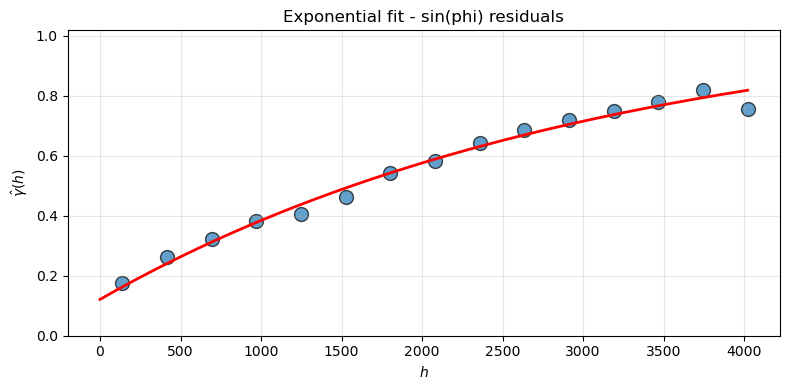

Residual Cos exponential fit: nugget=0.09335, sill=0.27095, range=1046.66 km


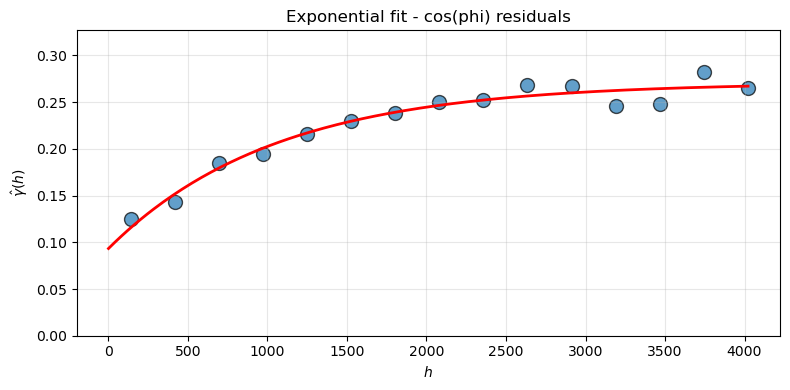

At 1.74 Ma: obliquity=23.2441 deg, eccentricity=0.05295, climatic precession=-0.05097
Written: Krigging Phi/PrecPhi1_1_74Ma_reconstructed.tif
Written: Krigging Phi/sin_PrecPhi1_1_74Ma.tif
Written: Krigging Phi/cos_PrecPhi1_1_74Ma.tif


In [43]:

sin_phi_2 = np.sin(data["PrecPhi1"].values)
cos_phi_2 = np.cos(data["PrecPhi1"].values)

orbital_today = la2004[la2004["t"] == 0].iloc[0]

X = build_design_matrix_v2(
    latitude=latitude,
    obliquity_rad=orbital_today["obliquity_rad"],
    climatic_precession=orbital_today["eccentricity"] * np.sin(orbital_today["pibar_rad"])
)

beta_sin, z_fitted_sin, residuals_sin, r2_sin = fit_trend_ols(X, sin_phi_2)

print("Fitted coefficients for Sin Phi:")
labels = ["intercept", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_sin):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_sin:.4f}")

beta, residuals_ss, rank, sv = np.linalg.lstsq(X, sin_phi_2, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]}")

X_cos = X
beta_cos, z_fitted_cos, residuals_cos, r2_cos = fit_trend_ols(X_cos, cos_phi_2)

print("\n\nFitted coefficients for Cos Phi:")
labels = ["intercept", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_cos):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_cos:.4f}")

beta, residuals_ss, rank, sv = np.linalg.lstsq(X, cos_phi_2, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]}")

lag_centers_r, gamma_hat_r, n_pairs_r = empirical_variogram(
    distance_matrix, residuals_sin, n_bins=15
)

exp_params_resid, exp_pcov_resid = fit_variogram_model(
    exponential_model, lag_centers_r, gamma_hat_r, n_pairs_r
)

print(f"Residual Sin exponential fit: nugget={exp_params_resid[0]:.5f}, "
      f"sill={exp_params_resid[1]:.5f}, range={exp_params_resid[2]:.2f} km")

plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      exponential_model, exp_params_resid,
                      title="Exponential fit - sin(phi) residuals")

lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos = empirical_variogram(
    distance_matrix, residuals_cos, n_bins=15
)

exp_params_resid_cos, exp_pcov_resid_cos = fit_variogram_model(
    exponential_model, lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos
)

print(f"Residual Cos exponential fit: nugget={exp_params_resid_cos[0]:.5f}, "
      f"sill={exp_params_resid_cos[1]:.5f}, range={exp_params_resid_cos[2]:.2f} km")

plot_variogram_curve(lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos,
                      exponential_model, exp_params_resid_cos,
                      title="Exponential fit - cos(phi) residuals")

Gamma_sin = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid)
A_sin = build_krigging_system(Gamma_sin)
A_inv_sin = np.linalg.inv(A_sin)

Gamma_cos = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid_cos)
A_cos = build_krigging_system(Gamma_cos)
A_inv_cos = np.linalg.inv(A_cos)

resid_sin_pred, resid_sin_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_sin,
    exponential_model, exp_params_resid, A_inv_sin
)

resid_cos_pred, resid_cos_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_cos,
    exponential_model, exp_params_resid_cos, A_inv_cos
)

target_t = -1740

obliquity_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["obliquity_rad"].values[::-1])
ecc_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["eccentricity"].values[::-1])
pibar_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["pibar_rad"].values[::-1])
precession_174 = ecc_174 * np.sin(pibar_174)

print(f"At 1.74 Ma: obliquity={np.degrees(obliquity_174):.4f} deg, "
      f"eccentricity={ecc_174:.5f}, climatic precession={precession_174:.5f}")

lat_inside_rad = np.radians(lat_inside)
trend_sin_174 = (beta_sin[0] +
                  beta_sin[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta_sin[2] * obliquity_174 * np.abs(lat_inside_rad))

trend_cos_174 = (beta_cos[0] +
                  beta_cos[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta_cos[2] * obliquity_174 * np.abs(lat_inside_rad))

sin_pred_174 = trend_sin_174 + resid_sin_pred
cos_pred_174 = trend_cos_174 + resid_cos_pred

phi_pred_174 = np.mod(np.arctan2(sin_pred_174, cos_pred_174), 2*np.pi)

nodata_value = -9999.0

def reassemble_raster(values_inside, inside_mask, grid_shape, nodata_value):
    full = np.full(inside_mask.shape, nodata_value)
    full[inside_mask] = values_inside
    raster = full.reshape(grid_shape)
    raster = np.flipud(raster)  # north-up orientation for GeoTIFF convention
    return raster

sin_raster_174 = reassemble_raster(sin_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)
cos_raster_174 = reassemble_raster(cos_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)
phi_raster_174 = reassemble_raster(phi_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)

total_var_174 = resid_sin_var + resid_cos_var
var_raster_174 = reassemble_raster(total_var_174, inside_mask, grid_long_mesh.shape, nodata_value)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

def write_geotiff(filepath, raster, transform, nodata_value):
    with rasterio.open(
        filepath, "w",
        driver="GTiff",
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=raster.dtype,
        crs="EPSG:4326",
        transform=transform,
        nodata=nodata_value,
    ) as dst:
        dst.write(raster, 1)
    print(f"Written: {filepath}")

write_geotiff("Krigging Phi/PrecPhi1_1_74Ma_reconstructed.tif", phi_raster_174, transform, nodata_value)
write_geotiff("Krigging Phi/sin_PrecPhi1_1_74Ma.tif", sin_raster_174, transform, nodata_value)
write_geotiff("Krigging Phi/cos_PrecPhi1_1_74Ma.tif", cos_raster_174, transform, nodata_value)
#write_geotiff("Krigging Phi/kriging_variance_1.74Ma.tif", var_raster_174, transform, nodata_value)

# Precipitation Phi 2

Fitted coefficients for Sin Phi:
  intercept: -0.41671
  precession*sin(lat): -37.92374
  obliquity*|lat|: 1.90522

Trend R²: 0.1305
Rank: 3 out of 3


Fitted coefficients for Cos Phi:
  intercept: -0.26249
  precession*sin(lat): -6.33512
  obliquity*|lat|: 2.90042

Trend R²: 0.0985
Rank: 3 out of 3
Residual Sin exponential fit: nugget=0.00000, sill=0.38164, range=565.21 km


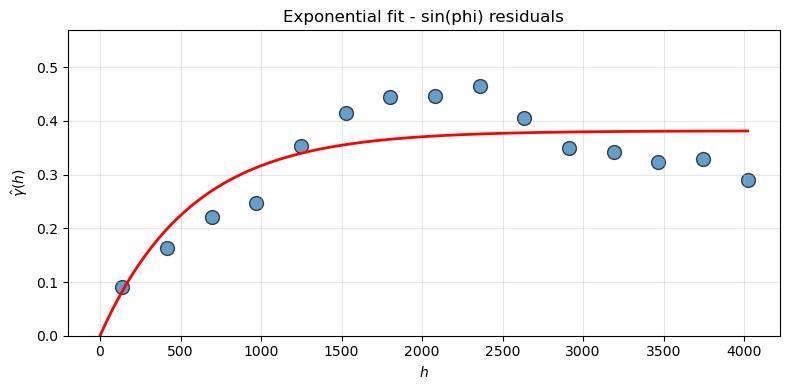

Residual Cos exponential fit: nugget=0.00000, sill=0.52374, range=779.86 km


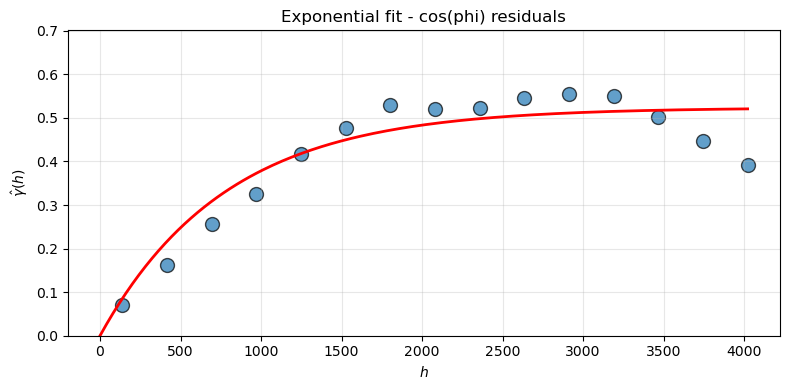

At 1.74 Ma: obliquity=23.2441 deg, eccentricity=0.05295, climatic precession=-0.05097
Written: Krigging Phi/PrecPhi2_1_74Ma_reconstructed.tif
Written: Krigging Phi/sin_PrecPhi2_1_74Ma.tif
Written: Krigging Phi/cos_PrecPhi2_1_74Ma.tif


In [44]:

sin_phi_2 = np.sin(data["PrecPhi2"].values)
cos_phi_2 = np.cos(data["PrecPhi2"].values)

orbital_today = la2004[la2004["t"] == 0].iloc[0]

X = build_design_matrix_v2(
    latitude=latitude,
    obliquity_rad=orbital_today["obliquity_rad"],
    climatic_precession=orbital_today["eccentricity"] * np.sin(orbital_today["pibar_rad"])
)

beta_sin, z_fitted_sin, residuals_sin, r2_sin = fit_trend_ols(X, sin_phi_2)

print("Fitted coefficients for Sin Phi:")
labels = ["intercept", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_sin):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_sin:.4f}")

beta, residuals_ss, rank, sv = np.linalg.lstsq(X, sin_phi_2, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]}")

X_cos = X
beta_cos, z_fitted_cos, residuals_cos, r2_cos = fit_trend_ols(X_cos, cos_phi_2)

print("\n\nFitted coefficients for Cos Phi:")
labels = ["intercept", "precession*sin(lat)", "obliquity*|lat|"]
for lbl, b in zip(labels, beta_cos):
    print(f"  {lbl}: {b:.5f}")
print(f"\nTrend R²: {r2_cos:.4f}")

beta, residuals_ss, rank, sv = np.linalg.lstsq(X, cos_phi_2, rcond=None)
print(f"Rank: {rank} out of {X.shape[1]}")

lag_centers_r, gamma_hat_r, n_pairs_r = empirical_variogram(
    distance_matrix, residuals_sin, n_bins=15
)

exp_params_resid, exp_pcov_resid = fit_variogram_model(
    exponential_model, lag_centers_r, gamma_hat_r, n_pairs_r
)

print(f"Residual Sin exponential fit: nugget={exp_params_resid[0]:.5f}, "
      f"sill={exp_params_resid[1]:.5f}, range={exp_params_resid[2]:.2f} km")

plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      exponential_model, exp_params_resid,
                      title="Exponential fit - sin(phi) residuals")

lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos = empirical_variogram(
    distance_matrix, residuals_cos, n_bins=15
)

exp_params_resid_cos, exp_pcov_resid_cos = fit_variogram_model(
    exponential_model, lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos
)

print(f"Residual Cos exponential fit: nugget={exp_params_resid_cos[0]:.5f}, "
      f"sill={exp_params_resid_cos[1]:.5f}, range={exp_params_resid_cos[2]:.2f} km")

plot_variogram_curve(lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos,
                      exponential_model, exp_params_resid_cos,
                      title="Exponential fit - cos(phi) residuals")

Gamma_sin = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid)
A_sin = build_krigging_system(Gamma_sin)
A_inv_sin = np.linalg.inv(A_sin)

Gamma_cos = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid_cos)
A_cos = build_krigging_system(Gamma_cos)
A_inv_cos = np.linalg.inv(A_cos)

resid_sin_pred, resid_sin_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_sin,
    exponential_model, exp_params_resid, A_inv_sin
)

resid_cos_pred, resid_cos_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_cos,
    exponential_model, exp_params_resid_cos, A_inv_cos
)

target_t = -1740

obliquity_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["obliquity_rad"].values[::-1])
ecc_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["eccentricity"].values[::-1])
pibar_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["pibar_rad"].values[::-1])
precession_174 = ecc_174 * np.sin(pibar_174)

print(f"At 1.74 Ma: obliquity={np.degrees(obliquity_174):.4f} deg, "
      f"eccentricity={ecc_174:.5f}, climatic precession={precession_174:.5f}")

lat_inside_rad = np.radians(lat_inside)
trend_sin_174 = (beta_sin[0] +
                  beta_sin[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta_sin[2] * obliquity_174 * np.abs(lat_inside_rad))

trend_cos_174 = (beta_cos[0] +
                  beta_cos[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta_cos[2] * obliquity_174 * np.abs(lat_inside_rad))

sin_pred_174 = trend_sin_174 + resid_sin_pred
cos_pred_174 = trend_cos_174 + resid_cos_pred

phi_pred_174 = np.mod(np.arctan2(sin_pred_174, cos_pred_174), 2*np.pi)

nodata_value = -9999.0

def reassemble_raster(values_inside, inside_mask, grid_shape, nodata_value):
    full = np.full(inside_mask.shape, nodata_value)
    full[inside_mask] = values_inside
    raster = full.reshape(grid_shape)
    raster = np.flipud(raster)  # north-up orientation for GeoTIFF convention
    return raster

sin_raster_174 = reassemble_raster(sin_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)
cos_raster_174 = reassemble_raster(cos_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)
phi_raster_174 = reassemble_raster(phi_pred_174, inside_mask, grid_long_mesh.shape, nodata_value)

total_var_174 = resid_sin_var + resid_cos_var
var_raster_174 = reassemble_raster(total_var_174, inside_mask, grid_long_mesh.shape, nodata_value)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

def write_geotiff(filepath, raster, transform, nodata_value):
    with rasterio.open(
        filepath, "w",
        driver="GTiff",
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=raster.dtype,
        crs="EPSG:4326",
        transform=transform,
        nodata=nodata_value,
    ) as dst:
        dst.write(raster, 1)
    print(f"Written: {filepath}")

write_geotiff("Krigging Phi/PrecPhi2_1_74Ma_reconstructed.tif", phi_raster_174, transform, nodata_value)
write_geotiff("Krigging Phi/sin_PrecPhi2_1_74Ma.tif", sin_raster_174, transform, nodata_value)
write_geotiff("Krigging Phi/cos_PrecPhi2_1_74Ma.tif", cos_raster_174, transform, nodata_value)
#write_geotiff("Krigging Phi/kriging_variance_1.74Ma.tif", var_raster_174, transform, nodata_value)

In [49]:

import os
import numpy as np
import rasterio
from rasterio.transform import from_origin

# make output folder
output_dir = "Krigging Phi/Evolution of Time 10 Ka"
os.makedirs(output_dir, exist_ok=True)

nodata_value = -9999.0

def reassemble_raster(values_inside, inside_mask, grid_shape, nodata_value):
    full = np.full(inside_mask.shape, nodata_value)
    full[inside_mask] = values_inside
    raster = full.reshape(grid_shape)
    raster = np.flipud(raster)
    return raster

def write_geotiff(filepath, raster, transform, nodata_value):
    with rasterio.open(
        filepath, "w",
        driver="GTiff",
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=raster.dtype,
        crs="EPSG:4326",
        transform=transform,
        nodata=nodata_value,
    ) as dst:
        dst.write(raster, 1)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)
lat_inside_rad = np.radians(lat_inside)

orbital_today = la2004[la2004["t"] == 0].iloc[0]

X = build_design_matrix_v2(
    latitude=latitude,
    obliquity_rad=orbital_today["obliquity_rad"],
    climatic_precession=orbital_today["eccentricity"] * np.sin(orbital_today["pibar_rad"])
)

beta_sin, z_fitted_sin, residuals_sin, r2_sin = fit_trend_ols(X, sin_phi)
X_cos = X
beta_cos, z_fitted_cos, residuals_cos, r2_cos = fit_trend_ols(X_cos, cos_phi)

lag_centers_r, gamma_hat_r, n_pairs_r = empirical_variogram(
    distance_matrix, residuals_sin, n_bins=15
)

exp_params_resid, exp_pcov_resid = fit_variogram_model(
    exponential_model, lag_centers_r, gamma_hat_r, n_pairs_r
)

lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos = empirical_variogram(
    distance_matrix, residuals_cos, n_bins=15
)

exp_params_resid_cos, exp_pcov_resid_cos = fit_variogram_model(
    exponential_model, lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos
)

Gamma_sin = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid)
A_sin = build_krigging_system(Gamma_sin)
A_inv_sin = np.linalg.inv(A_sin)

Gamma_cos = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid_cos)
A_cos = build_krigging_system(Gamma_cos)
A_inv_cos = np.linalg.inv(A_cos)

resid_sin_pred, resid_sin_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_sin,
    exponential_model, exp_params_resid, A_inv_sin
)

resid_cos_pred, resid_cos_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_cos,
    exponential_model, exp_params_resid_cos, A_inv_cos
)

#ages_ma = np.arange(0.1, 3.3 + 0.01, 0.1)  # 0.1, 0.2, ..., 3.3
#ages_ma = np.arange(0.01, 3.3 + 0.001, 0.01)
ages_ma = np.arange(0.001, 3.3 + 0.0001, 0.001)

for age_ma in ages_ma:
    target_t = -age_ma * 1000  # convert Ma to kyr, apply La2004 sign convention

    obliquity_t = np.interp(target_t, la2004["t"].values[::-1], la2004["obliquity_rad"].values[::-1])
    ecc_t = np.interp(target_t, la2004["t"].values[::-1], la2004["eccentricity"].values[::-1])
    pibar_t = np.interp(target_t, la2004["t"].values[::-1], la2004["pibar_rad"].values[::-1])
    precession_t = ecc_t * np.sin(pibar_t)

    trend_sin_t = (beta_sin[0] +
                   beta_sin[1] * precession_t * np.sin(lat_inside_rad) +
                   beta_sin[2] * obliquity_t * np.abs(lat_inside_rad))

    trend_cos_t = (beta_cos[0] +
                   beta_cos[1] * precession_t * np.sin(lat_inside_rad) +
                   beta_cos[2] * obliquity_t * np.abs(lat_inside_rad))

    sin_pred_t = trend_sin_t + resid_sin_pred
    cos_pred_t = trend_cos_t + resid_cos_pred

    phi_pred_t = np.mod(np.arctan2(sin_pred_t, cos_pred_t), 2 * np.pi)

    phi_raster_t = reassemble_raster(phi_pred_t, inside_mask, grid_long_mesh.shape, nodata_value)

    # filename e.g. TempPhi1_0.1Ma.tif, TempPhi1_1.7Ma.tif, TempPhi1_3.3Ma.tif
    filename = f"TempPhi1_{age_ma:.4f}Ma.tif"
    filepath = os.path.join(output_dir, filename)
    write_geotiff(filepath, phi_raster_t, transform, nodata_value)

    print(f"Written: {filename}  (obliquity={np.degrees(obliquity_t):.3f} deg, "
          f"ecc={ecc_t:.5f}, precession={precession_t:.5f})")

print(f"\nDone - {len(ages_ma)} rasters written to '{output_dir}'")

Written: TempPhi1_0.0010Ma.tif  (obliquity=23.569 deg, ecc=0.01716, precession=0.01712)
Written: TempPhi1_0.0020Ma.tif  (obliquity=23.695 deg, ecc=0.01750, precession=0.01631)
Written: TempPhi1_0.0030Ma.tif  (obliquity=23.814 deg, ecc=0.01785, precession=0.01402)
Written: TempPhi1_0.0040Ma.tif  (obliquity=23.924 deg, ecc=0.01821, precession=0.01045)
Written: TempPhi1_0.0050Ma.tif  (obliquity=24.021 deg, ecc=0.01845, precession=0.00573)
Written: TempPhi1_0.0060Ma.tif  (obliquity=24.102 deg, ecc=0.01875, precession=0.00046)
Written: TempPhi1_0.0070Ma.tif  (obliquity=24.166 deg, ecc=0.01894, precession=-0.00495)
Written: TempPhi1_0.0080Ma.tif  (obliquity=24.210 deg, ecc=0.01918, precession=-0.01012)
Written: TempPhi1_0.0090Ma.tif  (obliquity=24.231 deg, ecc=0.01933, precession=-0.01445)
Written: TempPhi1_0.0100Ma.tif  (obliquity=24.231 deg, ecc=0.01942, precession=-0.01757)
Written: TempPhi1_0.0110Ma.tif  (obliquity=24.207 deg, ecc=0.01960, precession=-0.01937)
Written: TempPhi1_0.0120Ma.

In [46]:

import os
import numpy as np
import rasterio
from rasterio.transform import from_origin

sin_phi_2 = np.sin(data["PrecPhi1"].values)
cos_phi_2 = np.cos(data["PrecPhi1"].values)

# make output folder
output_dir = "Krigging Phi/Precipitation Evolution of Time 10 Ka"
os.makedirs(output_dir, exist_ok=True)

nodata_value = -9999.0

def reassemble_raster(values_inside, inside_mask, grid_shape, nodata_value):
    full = np.full(inside_mask.shape, nodata_value)
    full[inside_mask] = values_inside
    raster = full.reshape(grid_shape)
    raster = np.flipud(raster)
    return raster

def write_geotiff(filepath, raster, transform, nodata_value):
    with rasterio.open(
        filepath, "w",
        driver="GTiff",
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=raster.dtype,
        crs="EPSG:4326",
        transform=transform,
        nodata=nodata_value,
    ) as dst:
        dst.write(raster, 1)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)
lat_inside_rad = np.radians(lat_inside)

orbital_today = la2004[la2004["t"] == 0].iloc[0]

X = build_design_matrix_v2(
    latitude=latitude,
    obliquity_rad=orbital_today["obliquity_rad"],
    climatic_precession=orbital_today["eccentricity"] * np.sin(orbital_today["pibar_rad"])
)

beta_sin, z_fitted_sin, residuals_sin, r2_sin = fit_trend_ols(X, sin_phi_2)
X_cos = X
beta_cos, z_fitted_cos, residuals_cos, r2_cos = fit_trend_ols(X_cos, cos_phi_2)

lag_centers_r, gamma_hat_r, n_pairs_r = empirical_variogram(
    distance_matrix, residuals_sin, n_bins=15
)

exp_params_resid, exp_pcov_resid = fit_variogram_model(
    exponential_model, lag_centers_r, gamma_hat_r, n_pairs_r
)

lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos = empirical_variogram(
    distance_matrix, residuals_cos, n_bins=15
)

exp_params_resid_cos, exp_pcov_resid_cos = fit_variogram_model(
    exponential_model, lag_centers_rcos, gamma_hat_rcos, n_pairs_rcos
)

Gamma_sin = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid)
A_sin = build_krigging_system(Gamma_sin)
A_inv_sin = np.linalg.inv(A_sin)

Gamma_cos = build_gamma_matrix(distance_matrix, exponential_model, exp_params_resid_cos)
A_cos = build_krigging_system(Gamma_cos)
A_inv_cos = np.linalg.inv(A_cos)

resid_sin_pred, resid_sin_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_sin,
    exponential_model, exp_params_resid, A_inv_sin
)

resid_cos_pred, resid_cos_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals_cos,
    exponential_model, exp_params_resid_cos, A_inv_cos
)

#ages_ma = np.arange(0.1, 3.3 + 0.01, 0.1)  # 0.1, 0.2, ..., 3.3
ages_ma = np.arange(0.01, 3.3 + 0.001, 0.01)

for age_ma in ages_ma:
    target_t = -age_ma * 1000  # convert Ma to kyr, apply La2004 sign convention

    obliquity_t = np.interp(target_t, la2004["t"].values[::-1], la2004["obliquity_rad"].values[::-1])
    ecc_t = np.interp(target_t, la2004["t"].values[::-1], la2004["eccentricity"].values[::-1])
    pibar_t = np.interp(target_t, la2004["t"].values[::-1], la2004["pibar_rad"].values[::-1])
    precession_t = ecc_t * np.sin(pibar_t)

    trend_sin_t = (beta_sin[0] +
                   beta_sin[1] * precession_t * np.sin(lat_inside_rad) +
                   beta_sin[2] * obliquity_t * np.abs(lat_inside_rad))

    trend_cos_t = (beta_cos[0] +
                   beta_cos[1] * precession_t * np.sin(lat_inside_rad) +
                   beta_cos[2] * obliquity_t * np.abs(lat_inside_rad))

    sin_pred_t = trend_sin_t + resid_sin_pred
    cos_pred_t = trend_cos_t + resid_cos_pred

    phi_pred_t = np.mod(np.arctan2(sin_pred_t, cos_pred_t), 2 * np.pi)

    phi_raster_t = reassemble_raster(phi_pred_t, inside_mask, grid_long_mesh.shape, nodata_value)

    # filename e.g. TempPhi1_0.1Ma.tif, TempPhi1_1.7Ma.tif, TempPhi1_3.3Ma.tif
    filename = f"PrecPhi1_{age_ma:.4f}Ma.tif"
    filepath = os.path.join(output_dir, filename)
    write_geotiff(filepath, phi_raster_t, transform, nodata_value)

    print(f"Written: {filename}  (obliquity={np.degrees(obliquity_t):.3f} deg, "
          f"ecc={ecc_t:.5f}, precession={precession_t:.5f})")

print(f"\nDone - {len(ages_ma)} rasters written to '{output_dir}'")

Written: PrecPhi1_0.0Ma.tif  (obliquity=24.231 deg, ecc=0.01942, precession=-0.01757)
Written: PrecPhi1_0.0Ma.tif  (obliquity=23.129 deg, ecc=0.01900, precession=0.01419)
Written: PrecPhi1_0.0Ma.tif  (obliquity=22.230 deg, ecc=0.01637, precession=-0.00830)
Written: PrecPhi1_0.0Ma.tif  (obliquity=23.604 deg, ecc=0.01393, precession=-0.00040)
Written: PrecPhi1_0.1Ma.tif  (obliquity=24.411 deg, ecc=0.01460, precession=0.01084)
Written: PrecPhi1_0.1Ma.tif  (obliquity=23.233 deg, ecc=0.01847, precession=-0.01844)
Written: PrecPhi1_0.1Ma.tif  (obliquity=22.341 deg, ecc=0.02328, precession=0.02159)
Written: PrecPhi1_0.1Ma.tif  (obliquity=23.198 deg, ecc=0.02880, precession=-0.02087)
Written: PrecPhi1_0.1Ma.tif  (obliquity=24.233 deg, ecc=0.03474, precession=0.01342)
Written: PrecPhi1_0.1Ma.tif  (obliquity=23.665 deg, ecc=0.04006, precession=-0.00065)
Written: PrecPhi1_0.1Ma.tif  (obliquity=22.388 deg, ecc=0.04342, precession=-0.01027)
Written: PrecPhi1_0.1Ma.tif  (obliquity=23.082 deg, ecc=0.